# HAAL Loss + C1 (ConvNeXt V2-T + EDL + HAAL)

This notebook implements the **HAAL loss**, trains **C1** (ConvNeXt V2-T + EDL + HAAL), runs the
`lambda_max` / `T_warmup` / `C` ablations on fold 0, and checks **Milestone M3** — exactly as in
the previous version of this notebook.

Everything under `experiments/C1_ConvNeXtV2T_EDL_HAAL/` below follows the template's structure
as closely as the actual content of this phase allows, with a few clearly-marked additions
(`haal_ablation` sub-folders).

## Folder map for this notebook

```
LIDC_Thesis/
├── LIDC/processed/
│   ├── metadata/   nodule_metadata_filtered.csv, fold_assignments.csv   [read]
│   └── arrays/     patches_224.npz                                     [read]
│
└── experiments/C1_ConvNeXtV2T_EDL_HAAL/
    ├── configs/      C1_config.yaml, split_config.json, random_seeds.json, haal_hyperparams.json
    ├── splits/fold_0/  train.csv, validation.csv, test.csv, fold_summary.csv
    ├── checkpoints/
    │   ├── fold_0/            best_model.pt, final_model.pt   (the official C1 model)
    │   └── ablation_runs/     one sub-folder per ablation run (search phase only)
    ├── predictions/deterministic/  fold_0_predictions.csv   (C1 is single-pass, no MC folder)
    ├── metrics/
    │   ├── classification/   fold_metrics.csv, overall_metrics.csv
    │   ├── calibration/      brier_scores.csv, ece_scores.csv, nll_scores.csv
    │   ├── uncertainty/      entropy_summary.csv, rejection_curves.csv
    │   └── haal_ablation/    lambda_max_sweep.csv, t_warmup_sweep.csv, prior_c_sweep.csv  [added]
    ├── gradcam/fold_0/       (reserved, empty — Weeks 9-10 ESM work)
    ├── plots/
    │   ├── training_curves/, confusion_matrices/, roc_curves/,
    │   ├── calibration_diagrams/, reliability_diagrams/, rejection_curves/,
    │   └── haal_ablation/    [added]
    ├── logs/         training_log.csv, fold_0.log
    └── reports/      C1_results_summary.csv, C1_results_summary.json, C1_experiment_notes.md
```


## 1. Environment Setup

Mounts Google Drive and installs `timm` (ConvNeXt V2 backbone) and `pyyaml` (to write the `.yaml` config file).

In [ ]:
import os
from google.colab import drive

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')
else:
    print("Google Drive already mounted.")

!pip install -q timm pyyaml
print("Done.")


Mounted at /content/drive
Done.


In [ ]:
import sys, math, random, warnings, json as jsonlib
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.transforms import v2

import timm

from sklearn.model_selection import StratifiedKFold, KFold, GroupShuffleSplit
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, confusion_matrix

warnings.filterwarnings("ignore", category=UserWarning)

print("Python      :", sys.version.split()[0])
print("PyTorch     :", torch.__version__, "| CUDA available:", torch.cuda.is_available())
print("Torchvision :", torchvision.__version__)
print("timm        :", timm.__version__)
print("Pandas      :", pd.__version__, "| NumPy:", np.__version__)

if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Go to Runtime > Change runtime type > Hardware accelerator > GPU.")
    print("Training ConvNeXt V2-T on CPU will be extremely slow.")


Python      : 3.13.15
PyTorch     : 2.11.0+cu128 | CUDA available: True
Torchvision : 0.26.0+cu128
timm        : 1.0.29
Pandas      : 2.2.3 | NumPy: 2.1.3
GPU         : Tesla T4


## 2. Configuration

Builds the full Drive folder tree shown above and creates every sub-folder

In [ ]:
EXPERIMENT_ID = "C1_ConvNeXtV2T_EDL_HAAL"

CONFIG = {
    # ------------------------------------------------------------------
    # Google Drive project root
    # ------------------------------------------------------------------
    "drive_root": "/content/drive/MyDrive/LIDC_Thesis",

    # Current folder.rtf layout
    "processed_root": "LIDC/processed",
    "metadata_dir": "LIDC/processed/metadata",
    "patches_dir": "LIDC/processed/patches",
    "arrays_dir": "LIDC/processed/arrays",

    # Metadata candidates, checked in order.
    "metadata_candidates": [
        "lidc_patches_metadata.csv",
        "detailed_nodule_metadata.csv",
        "nodule_metadata_filtered.csv",     # legacy preprocessing notebook
        "patch_manifest.csv",                # older pipeline variant
    ],
    "fold_candidates": [
        "fold_assignments.csv",
    ],

    # Optional consolidated patch archive fallback.
    "npz_candidates": [
        "LIDC/processed/arrays/patches_224.npz",
        "LIDC/processed/patches/patches_224.npz",
        "patches/patches_224.npz",
    ],

    # Individual-patch file extensions supported by the loader.
    "patch_extensions": [".npy", ".png", ".jpg", ".jpeg", ".tif", ".tiff"],

    # Output
    "experiment_id": EXPERIMENT_ID,
    "experiment_dir": f"experiments/{EXPERIMENT_ID}",

    # B3 comparison candidates (M3 only; training does not depend on these).
    "b3_results_candidates": [
        "experiments/B3_ResNet50_EDL/reports/B3_results_summary.csv",
        "outputs/week4_5_baselines/results/baseline_B1_B3_results.csv",
    ],

    # Canonical column names AFTER load_metadata() normalizes aliases.
    "column_map": {
        "patient_id": "patient_id",
        "nodule_id": "nodule_id",
        "patch_path": "patch_path",
        "label": "label_id",
        "label_name": "label_name",
        "V": "V",
        "alignment_mask": "alignment_mask",
        "n_annotators": "ni",
        "median_malignancy": "median_malignancy",
        "variance_raw": "population_variance",
        "diameter_mm": "diameter_mm",
        "fold": "fold",
    },

    "num_classes": 3,
    "class_names": ["benign", "indeterminate", "malignant"],
    "image_size": 224,

    # Training protocol
    "batch_size": 32,
    "num_workers": 2,
    "epochs": 50,
    "early_stop_patience": 10,
    "lr_init": 1e-4,
    "lr_min": 1e-6,
    "weight_decay": 0.01,
    "pretrained": True,
    "use_imagenet_norm": True,
    "seed": 42,

    # CV
    "n_folds": 5,
    "val_frac_of_trainval": 0.125,
    "min_nodules_for_kfold": 100,
    "smoke_test_mode": False,
    "small_sample_caution": False,

    # Model
    "convnext_model_name": "convnextv2_tiny.fcmae_ft_in1k",

    # HAAL defaults / Table 6
    "haal_lambda_max_default": 1.0,
    "haal_t_warmup_default": 10,
    "haal_prior_c_default": 1.0,
    "lambda_max_grid": [0.0, 0.1, 0.5, 1.0, 5.0],
    "t_warmup_grid": [0, 5, 10, 20],
    "prior_c_grid": [0.5, 1.0, 2.0],
    "ablation_epochs": 20,
    "ablation_patience": 6,

    # Evaluation
    "ece_bins": 15,
}

# --------------------------- derived paths ---------------------------
CONFIG["abs_processed_root"] = os.path.join(CONFIG["drive_root"], CONFIG["processed_root"])
CONFIG["abs_metadata_dir"] = os.path.join(CONFIG["drive_root"], CONFIG["metadata_dir"])
CONFIG["abs_patches_dir"] = os.path.join(CONFIG["drive_root"], CONFIG["patches_dir"])
CONFIG["abs_arrays_dir"] = os.path.join(CONFIG["drive_root"], CONFIG["arrays_dir"])

EXP_ROOT = os.path.join(CONFIG["drive_root"], CONFIG["experiment_dir"])
CONFIG["exp_root"] = EXP_ROOT
CONFIG["dir_configs"] = os.path.join(EXP_ROOT, "configs")
CONFIG["dir_splits"] = os.path.join(EXP_ROOT, "splits")
CONFIG["dir_ckpt_fold0"] = os.path.join(EXP_ROOT, "checkpoints", "fold_0")
CONFIG["dir_ckpt_ablation"] = os.path.join(EXP_ROOT, "checkpoints", "ablation_runs")
CONFIG["dir_predictions"] = os.path.join(EXP_ROOT, "predictions", "deterministic")
CONFIG["dir_metrics_classification"] = os.path.join(EXP_ROOT, "metrics", "classification")
CONFIG["dir_metrics_calibration"] = os.path.join(EXP_ROOT, "metrics", "calibration")
CONFIG["dir_metrics_uncertainty"] = os.path.join(EXP_ROOT, "metrics", "uncertainty")
CONFIG["dir_metrics_haal_ablation"] = os.path.join(EXP_ROOT, "metrics", "haal_ablation")
CONFIG["dir_gradcam_fold0"] = os.path.join(EXP_ROOT, "gradcam", "fold_0")
CONFIG["dir_plots_training"] = os.path.join(EXP_ROOT, "plots", "training_curves")
CONFIG["dir_plots_confusion"] = os.path.join(EXP_ROOT, "plots", "confusion_matrices")
CONFIG["dir_plots_roc"] = os.path.join(EXP_ROOT, "plots", "roc_curves")
CONFIG["dir_plots_calibration"] = os.path.join(EXP_ROOT, "plots", "calibration_diagrams")
CONFIG["dir_plots_reliability"] = os.path.join(EXP_ROOT, "plots", "reliability_diagrams")
CONFIG["dir_plots_rejection"] = os.path.join(EXP_ROOT, "plots", "rejection_curves")
CONFIG["dir_plots_haal_ablation"] = os.path.join(EXP_ROOT, "plots", "haal_ablation")
CONFIG["dir_logs"] = os.path.join(EXP_ROOT, "logs")
CONFIG["dir_reports"] = os.path.join(EXP_ROOT, "reports")

ALL_OUTPUT_DIRS = [v for k, v in CONFIG.items() if k.startswith("dir_")]
for d in ALL_OUTPUT_DIRS:
    os.makedirs(d, exist_ok=True)

CONFIG["device"] = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])

print("Device:", CONFIG["device"])
print("Processed root :", CONFIG["abs_processed_root"])
print("Metadata dir  :", CONFIG["abs_metadata_dir"])
print("Patch dir     :", CONFIG["abs_patches_dir"])
print("Output root   :", CONFIG["exp_root"])


Device: cuda
Processed root : /content/drive/MyDrive/LIDC_Thesis/LIDC/processed
Metadata dir  : /content/drive/MyDrive/LIDC_Thesis/LIDC/processed/metadata
Patch dir     : /content/drive/MyDrive/LIDC_Thesis/LIDC/processed/patches
Output root   : /content/drive/MyDrive/LIDC_Thesis/experiments/C1_ConvNeXtV2T_EDL_HAAL


## 3. Simple file logger

Template expects a `logs/fold_0.log` text file alongside the console output. This is a
tiny helper — `log(message)` — that both prints and appends to that file, used throughout the
notebook instead of a plain `print()`. Deliberately simple (no `logging` module configuration)
since it only needs to do one thing.


In [ ]:
LOG_FILE_PATH = os.path.join(CONFIG["dir_logs"], "fold_0.log")


def log(message=""):
    """Print a message AND append it to logs/fold_0.log with a timestamp."""
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(message)
    with open(LOG_FILE_PATH, "a") as f:
        f.write(f"[{timestamp}] {message}\n")


log(f"=== Week 6-8 HAAL / C1 run started: {datetime.now().isoformat()} ===")
log(f"Experiment folder: {CONFIG['exp_root']}")

=== Week 6-8 HAAL / C1 run started: 2026-09-19T12:17:07.006178 ===
Experiment folder: /content/drive/MyDrive/LIDC_Thesis/experiments/C1_ConvNeXtV2T_EDL_HAAL


## 4. Load and validate metadata

Same validation logic as before including `V` and
`alignment_mask`, which HAAL needs, checks for patient leakage across folds.


In [ ]:

import re
from pathlib import Path
import ast as py_ast

LABEL_TO_ID = {"benign": 0, "indeterminate": 1, "malignant": 2}
ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}

COLUMN_ALIASES = {
    "patient_id": ["patient_id", "patient", "patientid", "subject_id", "patient_uid"],
    "nodule_id": ["nodule_id", "nodule_key", "nodule", "nodule_uid", "patch_id", "lesion_id"],
    "patch_path": ["patch_path", "image_path", "file_path", "filepath", "patch_file", "image_file", "filename"],
    "label_id": ["label_id", "label", "class_id", "target", "y"],
    "label_name": ["label_name", "class_name", "class", "category"],
    "V": [
        "V", "v", "variance_target", "normalized_variance", "annotator_variance_norm",
        "normalized_annotator_variance", "variance_normalized"
    ],
    "alignment_mask": ["alignment_mask", "align_mask", "variance_mask", "haal_mask"],
    "ni": [
        "ni", "n_annotators", "num_annotators", "annotator_count", "reader_count",
        "num_readers", "n_readers"
    ],
    "median_malignancy": [
        "median_malignancy", "malignancy_median", "median_score", "median_malignancy_score"
    ],
    "population_variance": [
        "population_variance", "variance_raw", "malignancy_variance", "score_variance",
        "annotator_variance", "rating_variance"
    ],
    "diameter_mm": [
        "diameter_mm", "diameter_mean_mm", "mean_diameter_mm", "diameter",
        "diameter_mm_est"
    ],
    "fold": ["fold", "cv_fold", "fold_id", "kfold"],
    "raw_scores": [
        "raw_scores", "malignancy_scores", "scores", "reader_scores",
        "radiologist_scores", "annotator_scores", "malignancy_ratings",
        "malignancy_values"
    ],
}

def _clean_colname(x):
    return str(x).strip().replace("\\_", "_")

def _first_existing_column(df, names):
    lower_map = {_clean_colname(c).lower(): c for c in df.columns}
    for name in names:
        key = _clean_colname(name).lower()
        if key in lower_map:
            return lower_map[key]
    return None

def normalize_metadata_columns(df, verbose=True):
    """Normalize common metadata aliases to one canonical schema."""
    df = df.copy()
    # Some CSVs may literally contain escaped underscores from prior exports.
    df.columns = [_clean_colname(c) for c in df.columns]

    rename = {}
    for canonical, aliases in COLUMN_ALIASES.items():
        hit = _first_existing_column(df, aliases)
        if hit is not None and canonical not in df.columns:
            rename[hit] = canonical
    if rename:
        df = df.rename(columns=rename)
        if verbose:
            print("Normalized columns:", rename)
    return df

def _patch_key(value):
    """Stable join key based on patch filename without extension."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    s = str(value).strip().replace("\\", "/")
    if not s:
        return None
    return os.path.splitext(os.path.basename(s))[0].strip()

def _derive_id_from_patch_path(df):
    """
    Current per-file metadata may not have nodule_id. In that case the patch filename stem
    becomes the canonical nodule_id. This is safe because the patch file itself is the sample.
    """
    df = df.copy()
    if "patch_path" in df.columns:
        patch_keys = df["patch_path"].map(_patch_key)
        df["_patch_key"] = patch_keys

        if "nodule_id" not in df.columns:
            df["nodule_id"] = patch_keys
        else:
            nid = df["nodule_id"].astype("object")
            missing = nid.isna() | (nid.astype(str).str.strip() == "")
            df.loc[missing, "nodule_id"] = patch_keys[missing]
    elif "nodule_id" in df.columns:
        df["_patch_key"] = df["nodule_id"].astype(str).map(_patch_key)
    return df

def _parse_scores(value):
    if isinstance(value, (list, tuple, np.ndarray)):
        return [float(x) for x in value]
    if pd.isna(value):
        return []
    s = str(value).strip()
    try:
        x = py_ast.literal_eval(s)
        if isinstance(x, (list, tuple, np.ndarray)):
            return [float(v) for v in x]
    except Exception:
        pass
    nums = re.findall(r"[-+]?\d*\.?\d+", s)
    return [float(x) for x in nums]

def derive_haal_columns(df):
    """Derive all HAAL quantities that can be derived without inventing information."""
    df = _derive_id_from_patch_path(df.copy())

    if "label_name" in df.columns:
        df["label_name"] = df["label_name"].astype(str).str.strip().str.lower()
    if "label_id" not in df.columns and "label_name" in df.columns:
        df["label_id"] = df["label_name"].map(LABEL_TO_ID)
    if "label_name" not in df.columns and "label_id" in df.columns:
        df["label_name"] = pd.to_numeric(df["label_id"], errors="coerce").map(ID_TO_LABEL)

    # Derive reader statistics from raw score list where available.
    if "raw_scores" in df.columns:
        parsed = df["raw_scores"].apply(_parse_scores)
        if "ni" not in df.columns:
            df["ni"] = parsed.apply(len)
        if "population_variance" not in df.columns:
            df["population_variance"] = parsed.apply(
                lambda x: float(np.var(x, ddof=0)) if len(x) else np.nan
            )
        if "median_malignancy" not in df.columns:
            df["median_malignancy"] = parsed.apply(
                lambda x: float(np.median(x)) if len(x) else np.nan
            )

    if "median_malignancy" in df.columns:
        med = pd.to_numeric(df["median_malignancy"], errors="coerce")
        if "label_id" not in df.columns:
            df["label_id"] = np.select(
                [med <= 2, med == 3, med >= 4], [0, 1, 2], default=np.nan
            )
        if "label_name" not in df.columns:
            df["label_name"] = pd.Series(df["label_id"], index=df.index).map(ID_TO_LABEL)

    if "population_variance" in df.columns and "V" not in df.columns:
        df["V"] = pd.to_numeric(df["population_variance"], errors="coerce") / 4.0

    if "V" in df.columns:
        df["V"] = pd.to_numeric(df["V"], errors="coerce").clip(0.0, 1.0)
        if "alignment_mask" not in df.columns:
            df["alignment_mask"] = (df["V"] > 0).astype(int)

    return df

def _metadata_quality(df):
    """Prefer a table that actually contains the HAAL supervision fields."""
    score = 0
    weights = {
        "patch_path": 10, "patient_id": 10, "nodule_id": 5,
        "label_id": 10, "label_name": 3,
        "V": 50, "population_variance": 35, "raw_scores": 35,
        "alignment_mask": 15, "ni": 10, "fold": 5,
    }
    for c, w in weights.items():
        if c in df.columns:
            score += w
    return score

def inspect_metadata_directory(cfg):
    """Read every CSV once, normalize it, and print a compact schema audit."""
    meta_dir = Path(cfg["abs_metadata_dir"])
    if not meta_dir.exists():
        raise FileNotFoundError(f"Metadata directory not found: {meta_dir}")

    tables = {}
    print("\nMETADATA FILE AUDIT")
    print("-" * 100)
    for p in sorted(meta_dir.glob("*.csv")):
        try:
            raw = pd.read_csv(p)
            df = normalize_metadata_columns(raw, verbose=False)
            df = derive_haal_columns(df)
            tables[p.name] = df
            print(
                f"{p.name:<38} rows={len(df):<6} quality={_metadata_quality(df):<3} "
                f"columns={list(df.columns)}"
            )
        except Exception as e:
            print(f"{p.name:<38} ERROR reading file: {e}")
    print("-" * 100)
    return tables

def find_metadata_file(cfg, tables=None):
    """
    Choose the richest compatible patch-level metadata table.

    v3 change:
    Do NOT blindly prefer lidc_patches_metadata.csv.  If a detailed table contains
    radiologist scores / V / variance / ni, it should be the primary source because
    HAAL needs those fields.
    """
    meta_dir = Path(cfg["abs_metadata_dir"])
    if tables is None:
        tables = inspect_metadata_directory(cfg)

    compatible = []
    for name, df in tables.items():
        if "patient_id" in df.columns and "label_id" in df.columns and (
            "patch_path" in df.columns or "nodule_id" in df.columns
        ):
            compatible.append((_metadata_quality(df), len(df), name))

    if not compatible:
        raise FileNotFoundError(
            f"No patch-level metadata CSV found in {meta_dir}. "
            "Need patient_id + label + (image_path/patch_path or nodule_id)."
        )

    # Highest HAAL/data quality first; row count breaks ties.
    compatible.sort(reverse=True)
    best_quality, best_rows, best_name = compatible[0]

    print(
        f"Selected richest compatible metadata: {best_name} "
        f"(quality={best_quality}, rows={best_rows})"
    )
    return str(meta_dir / best_name)

def _merge_one_metadata_table(base, extra, extra_name):
    """
    Merge useful columns from another metadata table.
    Join priority:
      1. exact normalized patch filename stem (_patch_key)
      2. exact nodule_id
    No patient/label-only merge is attempted because that could silently attach the
    wrong radiologist variance to another nodule.
    """
    base = derive_haal_columns(base)
    extra = derive_haal_columns(extra)

    desired = [
        "V", "alignment_mask", "ni", "raw_scores", "population_variance",
        "median_malignancy", "diameter_mm", "fold"
    ]
    missing_fields = [c for c in desired if c not in base.columns]
    if not missing_fields:
        return base, False

    join_key = None
    if "_patch_key" in base.columns and "_patch_key" in extra.columns:
        bkeys = set(base["_patch_key"].dropna().astype(str))
        ekeys = set(extra["_patch_key"].dropna().astype(str))
        if len(bkeys & ekeys) > 0:
            join_key = "_patch_key"

    if join_key is None and "nodule_id" in base.columns and "nodule_id" in extra.columns:
        bkeys = set(base["nodule_id"].dropna().astype(str))
        ekeys = set(extra["nodule_id"].dropna().astype(str))
        if len(bkeys & ekeys) > 0:
            join_key = "nodule_id"

    if join_key is None:
        return base, False

    carry = [c for c in missing_fields if c in extra.columns]
    if not carry:
        return base, False

    rhs = extra[[join_key] + carry].copy()
    rhs[join_key] = rhs[join_key].astype(str)
    rhs = rhs.dropna(subset=[join_key]).drop_duplicates(join_key)

    left = base.copy()
    left[join_key] = left[join_key].astype(str)
    before_cols = set(left.columns)

    left = left.merge(rhs, on=join_key, how="left", validate="many_to_one")
    added = [c for c in carry if c in left.columns and c not in before_cols]

    if added:
        matched = int(left[added].notna().any(axis=1).sum())
        print(f"Merged from {extra_name} using {join_key}: fields={added}, matched_rows={matched}/{len(left)}")
        return derive_haal_columns(left), True

    return left, False

def enrich_from_all_metadata(df, cfg, tables, primary_name):
    """Merge HAAL supervision from every other metadata CSV that shares a safe sample key."""
    out = derive_haal_columns(df)
    # Richest tables first.
    others = sorted(
        [(name, table) for name, table in tables.items() if name != primary_name],
        key=lambda x: _metadata_quality(x[1]),
        reverse=True
    )
    for name, table in others:
        out, _ = _merge_one_metadata_table(out, table, name)
    return derive_haal_columns(out)

def find_fold_file(cfg):
    meta_dir = Path(cfg["abs_metadata_dir"])
    for name in cfg["fold_candidates"]:
        p = meta_dir / name
        if p.exists():
            return str(p)
    return None

def find_npz_archive(cfg):
    for rel in cfg["npz_candidates"]:
        p = Path(cfg["drive_root"]) / rel
        if p.exists():
            return str(p)
    return None

def build_patch_index(cfg):
    root = Path(cfg["abs_patches_dir"])
    index = {}
    duplicates = {}
    if not root.exists():
        return index, duplicates

    allowed = set(x.lower() for x in cfg["patch_extensions"])
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in allowed:
            keys = {p.stem, p.name}
            try:
                keys.add(str(p.relative_to(root)).replace("\\", "/"))
            except Exception:
                pass
            for key in keys:
                if key in index and index[key] != str(p):
                    duplicates.setdefault(key, []).append(str(p))
                else:
                    index[key] = str(p)
    return index, duplicates

def _candidate_patch_keys(row):
    keys = []
    for c in ["patch_path", "_patch_key", "nodule_id"]:
        if c in row.index and pd.notna(row[c]):
            s = str(row[c]).strip()
            keys.extend([s, os.path.basename(s), os.path.splitext(os.path.basename(s))[0]])
    return list(dict.fromkeys(keys))

def resolve_metadata_patch_paths(df, cfg):
    df = df.copy()
    patch_index, duplicates = build_patch_index(cfg)
    if duplicates:
        print(f"WARNING: {len(duplicates)} duplicate patch-name key(s); first match is used.")

    resolved = []
    for _, row in df.iterrows():
        found = None

        if "patch_path" in row.index and pd.notna(row["patch_path"]):
            raw = str(row["patch_path"]).strip()
            candidates = [
                raw,
                os.path.join(cfg["drive_root"], raw),
                os.path.join(cfg["abs_processed_root"], raw),
                os.path.join(cfg["abs_patches_dir"], raw),
            ]
            for p in candidates:
                if os.path.isfile(p):
                    found = os.path.abspath(p)
                    break

        if found is None:
            for key in _candidate_patch_keys(row):
                if key in patch_index:
                    found = patch_index[key]
                    break

        if found is None and "nodule_id" in row.index and pd.notna(row["nodule_id"]):
            nid = str(row["nodule_id"]).strip()
            label = str(row.get("label_name", "")).strip().lower()
            roots = [Path(cfg["abs_patches_dir"])]
            if label in LABEL_TO_ID:
                roots.insert(0, Path(cfg["abs_patches_dir"]) / label)
            for r in roots:
                for ext in cfg["patch_extensions"]:
                    p = r / f"{nid}{ext}"
                    if p.exists():
                        found = str(p)
                        break
                if found:
                    break

        resolved.append(found)

    df["patch_path"] = resolved
    df = _derive_id_from_patch_path(df)
    return df, int(pd.Series(resolved).notna().sum()), len(patch_index)

def load_metadata(cfg):
    # 1) Audit every metadata CSV and choose the actual patch manifest.
    tables = inspect_metadata_directory(cfg)
    meta_path = find_metadata_file(cfg, tables=tables)
    primary_name = os.path.basename(meta_path)

    df = tables[primary_name].copy()
    print(f"\nPrimary patch metadata selected: {primary_name}")

    # 2) Critical v2 fix: derive nodule_id from image/patch filename BEFORE merging.
    df = normalize_metadata_columns(df)
    df = derive_haal_columns(df)

    # v3 diagnostic: prove that malignancy_values/raw_scores were converted to HAAL targets.
    if "raw_scores" in df.columns:
        valid_scores = int(df["raw_scores"].apply(lambda x: len(_parse_scores(x)) > 0).sum())
        print(f"Radiologist score rows recognized: {valid_scores}/{len(df)}")
    if "population_variance" in df.columns:
        print(
            "Population variance derived:",
            int(pd.to_numeric(df["population_variance"], errors="coerce").notna().sum()),
            "rows"
        )
    if "V" in df.columns:
        print(
            "HAAL V derived:",
            int(pd.to_numeric(df["V"], errors="coerce").notna().sum()),
            "rows; range=",
            (
                float(pd.to_numeric(df["V"], errors="coerce").min()),
                float(pd.to_numeric(df["V"], errors="coerce").max())
            )
        )

    # 3) Pull V / reader scores / alignment_mask / fold from richer metadata tables.
    df = enrich_from_all_metadata(df, cfg, tables, primary_name)

    # 4) Optional legacy fold assignment merge.
    fold_path = find_fold_file(cfg)
    if "fold" not in df.columns and fold_path:
        df_fold = normalize_metadata_columns(pd.read_csv(fold_path))
        df_fold = derive_haal_columns(df_fold)

        joined = False
        for join_key in ["_patch_key", "nodule_id"]:
            if join_key in df.columns and join_key in df_fold.columns:
                common = set(df[join_key].dropna().astype(str)) & set(
                    df_fold[join_key].dropna().astype(str)
                )
                if common and "fold" in df_fold.columns:
                    rhs = df_fold[[join_key, "fold"]].drop_duplicates(join_key)
                    df = df.merge(rhs, on=join_key, how="left", validate="many_to_one")
                    print(f"Merged fold_assignments.csv using {join_key}.")
                    joined = True
                    break

    # 5) Resolve actual individual patch files.
    df, n_patch_paths, n_indexed = resolve_metadata_patch_paths(df, cfg)

    npz_path = find_npz_archive(cfg)
    if n_patch_paths == len(df) and len(df) > 0:
        cfg["patch_storage_mode"] = "individual_files"
        cfg["detected_npz"] = None
    elif npz_path is not None:
        cfg["patch_storage_mode"] = "npz"
        cfg["detected_npz"] = npz_path
        print(
            f"Individual patch matches: {n_patch_paths}/{len(df)}; "
            f"using legacy NPZ fallback: {npz_path}"
        )
    else:
        missing_rows = df[df["patch_path"].isna()]
        examples = missing_rows["nodule_id"].astype(str).head(10).tolist()
        raise FileNotFoundError(
            f"Could only match {n_patch_paths}/{len(df)} rows to individual patch files and "
            "no legacy NPZ fallback exists.\n"
            f"Patch root: {cfg['abs_patches_dir']}\n"
            f"Example unmatched IDs: {examples}"
        )

    # 6) Validate HAAL data contract. Never invent V.
    required = ["patient_id", "nodule_id", "label_id", "V", "alignment_mask"]
    missing = [c for c in required if c not in df.columns]

    if missing:
        print("\nFAILED HAAL DATA CONTRACT")
        print("=" * 100)
        print("Primary metadata:", primary_name)
        print("Current columns:", list(df.columns))
        print("\nMetadata files inspected:")
        for name, table in tables.items():
            useful = [
                c for c in [
                    "patient_id", "nodule_id", "_patch_key", "patch_path", "label_id",
                    "V", "population_variance", "raw_scores", "alignment_mask", "ni", "fold"
                ] if c in table.columns
            ]
            print(f"  - {name}: {useful}")
        print("=" * 100)

        raise KeyError(
            "HAAL training cannot proceed because these required fields are genuinely absent "
            f"after safe metadata merging: {missing}\n\n"
            "V cannot be reconstructed from class labels alone. It must come from one of:\n"
            "  • V / normalized_variance,\n"
            "  • population_variance / variance_raw (then V = variance/4), or\n"
            "  • raw radiologist malignancy scores (then variance and V are computed).\n\n"
            "The audit printed immediately above shows exactly which CSV contains which fields."
        )

    # 7) Clean types.
    df["patient_id"] = df["patient_id"].astype(str)
    df["nodule_id"] = df["nodule_id"].astype(str)
    df["label_id"] = pd.to_numeric(df["label_id"], errors="raise").astype(int)
    df["V"] = pd.to_numeric(df["V"], errors="raise").astype(float).clip(0, 1)
    df["alignment_mask"] = pd.to_numeric(
        df["alignment_mask"], errors="coerce"
    ).fillna((df["V"] > 0).astype(int)).astype(int)

    bad_labels = sorted(set(df["label_id"].unique()) - {0, 1, 2})
    if bad_labels:
        raise ValueError(f"Unexpected label_id values: {bad_labels}; expected 0/1/2.")

    # Project selection rules where fields exist.
    if "ni" in df.columns:
        df["ni"] = pd.to_numeric(df["ni"], errors="coerce")
        before = len(df)
        df = df[(df["ni"].isna()) | (df["ni"] >= 3)].reset_index(drop=True)
        if len(df) < before:
            print(f"Filtered {before-len(df)} row(s) with ni < 3.")

    if "diameter_mm" in df.columns:
        df["diameter_mm"] = pd.to_numeric(df["diameter_mm"], errors="coerce")
        before = len(df)
        df = df[(df["diameter_mm"].isna()) | (df["diameter_mm"] >= 3.0)].reset_index(drop=True)
        if len(df) < before:
            print(f"Filtered {before-len(df)} row(s) with diameter_mm < 3.")

    # Guard against accidental many-to-one / duplicate sample rows.
    dup = df["nodule_id"].duplicated(keep=False)
    if dup.any():
        examples = df.loc[dup, ["nodule_id", "patch_path"]].head(10)
        print("WARNING: duplicate nodule_id values detected; dropping exact duplicate patch rows.")
        df = df.drop_duplicates(subset=["patch_path"]).reset_index(drop=True)

    cfg["detected_metadata_csv"] = meta_path
    cfg["detected_fold_csv"] = fold_path

    print("\n" + "=" * 100)
    print("INPUT AUDIT — PASSED")
    print("=" * 100)
    print("Primary metadata :", meta_path)
    print("Patch mode       :", cfg["patch_storage_mode"])
    if cfg["patch_storage_mode"] == "individual_files":
        print("Patch root       :", cfg["abs_patches_dir"])
        print(f"Matched patches  : {n_patch_paths}/{len(df)}")
    else:
        print("NPZ archive      :", cfg["detected_npz"])
    print("Rows             :", len(df))
    print("Patients         :", df["patient_id"].nunique())
    print("V range          :", (float(df["V"].min()), float(df["V"].max())))
    print("V > 0 rows       :", int((df["V"] > 0).sum()))
    print("Classes:")
    print(df["label_id"].value_counts().sort_index())
    print("Alignment mask:")
    print(df["alignment_mask"].value_counts().sort_index())
    print("=" * 100)

    return df


In [ ]:
# extra code --- starts

import os
import glob
import pandas as pd

ROOT = "/content/drive/MyDrive/LIDC_Thesis/LIDC/processed"

print("=== METADATA ===")
for f in glob.glob(os.path.join(ROOT, "metadata", "*")):
    print(f)

print("\n=== ARRAYS ===")
for f in glob.glob(os.path.join(ROOT, "arrays", "*")):
    print(f)

print("\n=== PATCH EXAMPLES ===")
patch_files = glob.glob(
    os.path.join(ROOT, "patches", "**", "*"),
    recursive=True
)

patch_files = [p for p in patch_files if os.path.isfile(p)]

print("Number of individual patch files:", len(patch_files))

for p in patch_files[:50]:
    print(p)

# extra code --- ends

=== METADATA ===
/content/drive/MyDrive/LIDC_Thesis/LIDC/processed/metadata/lidc_patches_metadata_detailed.csv
/content/drive/MyDrive/LIDC_Thesis/LIDC/processed/metadata/detailed_nodule_metadata.csv
/content/drive/MyDrive/LIDC_Thesis/LIDC/processed/metadata/lidc_patches_metadata.csv
/content/drive/MyDrive/LIDC_Thesis/LIDC/processed/metadata/B1_effective_metadata.csv
/content/drive/MyDrive/LIDC_Thesis/LIDC/processed/metadata/B2_effective_metadata.csv

=== ARRAYS ===

=== PATCH EXAMPLES ===
Number of individual patch files: 94
/content/drive/MyDrive/LIDC_Thesis/LIDC/processed/patches/malignant/LIDC-IDRI-0001/LIDC-IDRI-0001_059720603192_cluster001_z0089.png
/content/drive/MyDrive/LIDC_Thesis/LIDC/processed/patches/malignant/LIDC-IDRI-0003/LIDC-IDRI-0003_033480003264_cluster001_z0077.png
/content/drive/MyDrive/LIDC_Thesis/LIDC/processed/patches/malignant/LIDC-IDRI-0007/LIDC-IDRI-0007_568330857680_cluster001_z0109.png
/content/drive/MyDrive/LIDC_Thesis/LIDC/processed/patches/malignant/LIDC-

In [ ]:
df_meta = load_metadata(CONFIG)
display(df_meta.head(94))

print("\nCanonical columns available:")
print(list(df_meta.columns))

if CONFIG["patch_storage_mode"] == "individual_files":
    print("\nSample resolved patch paths:")
    display(df_meta[["nodule_id", "label_id", "V", "patch_path"]].head(10))



METADATA FILE AUDIT
----------------------------------------------------------------------------------------------------
B1_effective_metadata.csv              rows=94     quality=38  columns=['patch_path', 'patient_id', 'label_id', 'label_name', 'nodule_id', '_patch_key']
B2_effective_metadata.csv              rows=94     quality=183 columns=['patch_path', 'patient_id', 'label_id', 'label_name', 'patch_filename', 'xml_path', 'series_uid', 'match_type', 'cluster_index', 'ni', 'reader_ids', 'median_malignancy', 'raw_scores', 'diameter_mm', 'slice_index', 'slice_z_mm', 'centroid_x_px', 'centroid_y_px', 'cross_section_area_px2', '_patch_key', 'nodule_id', 'population_variance', 'V', 'alignment_mask']
detailed_nodule_metadata.csv           rows=0      quality=38  columns=['patch_path', 'patient_id', 'label_id', 'label_name', 'diameter_mm', 'median_malignancy', 'slice_index', 'centroid_x', 'centroid_y', '_patch_key', 'nodule_id']
lidc_patches_metadata.csv              rows=0      quality=3

,patch_path,patient_id,label_id,label_name,xml_path,series_uid,match_type,cluster_index,ni,reader_ids,...,slice_index,slice_z_mm,centroid_x_px,centroid_y_px,cross_section_area_px2,_patch_key,nodule_id,population_variance,V,alignment_mask
0,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...,LIDC-IDRI-0001,2,malignant,/content/drive/MyDrive/LIDC_Thesis/LIDC/annota...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,exact_series_uid,1,4,-750896469|1428348137|2103845659|540461523,...,89,-117.50,311.0,362.0,3893.5,LIDC-IDRI-0001_059720603192_cluster001_z0089,LIDC-IDRI-0001_059720603192_cluster001_z0089,0.187500,0.046875,1
1,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...,LIDC-IDRI-0003,2,malignant,/content/drive/MyDrive/LIDC_Thesis/LIDC/annota...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,exact_series_uid,1,4,-1190943846|-1268390652|-649195566|-671528798,...,77,-186.50,367.0,354.0,2601.5,LIDC-IDRI-0003_033480003264_cluster001_z0077,LIDC-IDRI-0003_033480003264_cluster001_z0077,0.687500,0.171875,1
2,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...,LIDC-IDRI-0003,1,indeterminate,/content/drive/MyDrive/LIDC_Thesis/LIDC/annota...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,exact_series_uid,2,4,-1190943846|-1268390652|-649195566|-671528798,...,83,-171.50,307.0,198.0,477.5,LIDC-IDRI-0003_033480003264_cluster002_z0083,LIDC-IDRI-0003_033480003264_cluster002_z0083,0.687500,0.171875,1
3,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...,LIDC-IDRI-0003,1,indeterminate,/content/drive/MyDrive/LIDC_Thesis/LIDC/annota...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,exact_series_uid,3,4,-1190943846|-1268390652|-649195566|-671528798,...,84,-169.00,221.0,220.0,835.0,LIDC-IDRI-0003_033480003264_cluster003_z0084,LIDC-IDRI-0003_033480003264_cluster003_z0084,1.250000,0.312500,1
4,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...,LIDC-IDRI-0004,0,benign,/content/drive/MyDrive/LIDC_Thesis/LIDC/annota...,1.3.6.1.4.1.14519.5.2.1.6279.6001.323541312620...,exact_series_uid,1,4,-1404443585|-1502690827|-1892804310|623442059,...,76,-230.00,142.0,323.0,141.0,LIDC-IDRI-0004_852212458228_cluster001_z0076,LIDC-IDRI-0004_852212458228_cluster001_z0076,0.187500,0.046875,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...,LIDC-IDRI-0049,1,indeterminate,/content/drive/MyDrive/LIDC_Thesis/LIDC/annota...,1.3.6.1.4.1.14519.5.2.1.6279.6001.239358021703...,exact_series_uid,4,4,-1394255116|-622412717|-677900502|1788446915,...,69,-178.75,337.0,145.0,288.0,LIDC-IDRI-0049_639913775427_cluster004_z0069,LIDC-IDRI-0049_639913775427_cluster004_z0069,0.250000,0.062500,1
90,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...,LIDC-IDRI-0049,0,benign,/content/drive/MyDrive/LIDC_Thesis/LIDC/annota...,1.3.6.1.4.1.14519.5.2.1.6279.6001.239358021703...,exact_series_uid,5,4,-1394255116|-622412717|-677900502|1788446915,...,72,-171.25,170.0,201.0,348.0,LIDC-IDRI-0049_639913775427_cluster005_z0072,LIDC-IDRI-0049_639913775427_cluster005_z0072,0.187500,0.046875,1
91,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...,LIDC-IDRI-0049,0,benign,/content/drive/MyDrive/LIDC_Thesis/LIDC/annota...,1.3.6.1.4.1.14519.5.2.1.6279.6001.239358021703...,exact_series_uid,7,3,-1394255116|-622412717|1788446915,...,66,-186.25,332.0,365.0,363.5,LIDC-IDRI-0049_639913775427_cluster007_z0066,LIDC-IDRI-0049_639913775427_cluster007_z0066,0.222222,0.055556,1
92,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...,LIDC-IDRI-0049,0,benign,/content/drive/MyDrive/LIDC_Thesis/LIDC/annota...,1.3.6.1.4.1.14519.5.2.1.6279.6001.239358021703...,exact_series_uid,11,3,-1394255116|-622412717|1788446915,...,70,-176.25,358.0,172.0,175.5,LIDC-IDRI-0049_639913775427_cluster011_z0070,LIDC-IDRI-0049_639913775427_cluster011_z0070,0.240000,0.060000,1



Canonical columns available:
['patch_path', 'patient_id', 'label_id', 'label_name', 'xml_path', 'series_uid', 'match_type', 'cluster_index', 'ni', 'reader_ids', 'median_malignancy', 'raw_scores', 'diameter_mm', 'slice_index', 'slice_z_mm', 'centroid_x_px', 'centroid_y_px', 'cross_section_area_px2', '_patch_key', 'nodule_id', 'population_variance', 'V', 'alignment_mask']

Sample resolved patch paths:


,nodule_id,label_id,V,patch_path
0,LIDC-IDRI-0001_059720603192_cluster001_z0089,2,0.046875,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...
1,LIDC-IDRI-0003_033480003264_cluster001_z0077,2,0.171875,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...
2,LIDC-IDRI-0003_033480003264_cluster002_z0083,1,0.171875,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...
3,LIDC-IDRI-0003_033480003264_cluster003_z0084,1,0.312500,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...
4,LIDC-IDRI-0004_852212458228_cluster001_z0076,0,0.046875,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...
5,LIDC-IDRI-0005_327836686225_cluster001_z0077,1,0.046875,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...
6,LIDC-IDRI-0005_327836686225_cluster002_z0080,1,0.046875,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...
7,LIDC-IDRI-0006_417924920957_cluster002_z0084,1,0.125000,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...
8,LIDC-IDRI-0007_568330857680_cluster001_z0109,2,0.046875,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...
9,LIDC-IDRI-0008_812229821954_cluster001_z0071,1,0.055556,/content/drive/MyDrive/LIDC_Thesis/LIDC/proces...


## 5. Patient-level fold assignment


In [ ]:
def attach_holdout_split(df, cfg):
    col = cfg["column_map"]
    patients = df[col["patient_id"]].unique()
    rng = np.random.RandomState(cfg["seed"])
    rng.shuffle(patients)
    n = len(patients)
    n_test = max(1, int(round(n * 0.20)))
    n_val = max(1, int(round(n * 0.15))) if (n - n_test) > 1 else 0
    test_patients = set(patients[:n_test])
    val_patients = set(patients[n_test:n_test + n_val])

    def split_of(p):
        if p in test_patients:
            return "test"
        if p in val_patients:
            return "val"
        return "train"

    df = df.copy()
    df["split"] = df[col["patient_id"]].apply(split_of)
    df["fold"] = -1
    log("Smoke-test patient-level split (train/val/test):")
    log(str(df["split"].value_counts()))
    return df


def assign_folds(df, cfg):
    col = cfg["column_map"]
    n_nodules = len(df)
    n_patients = df[col["patient_id"]].nunique()

    has_fold_col = (col["fold"] in df.columns) and df[col["fold"]].notna().all() \
        and df[col["fold"]].nunique() >= 2

    if has_fold_col:
        leak = df.groupby(col["patient_id"])[col["fold"]].nunique()
        if (leak > 1).any():
            bad = leak[leak > 1].index.tolist()
            raise ValueError(f"Patient-level leakage in '{col['fold']}': patients {bad[:5]}.")
        df = df.copy()
        df["fold"] = df[col["fold"]]
        n_folds_found = df["fold"].nunique()
        cfg["n_folds"] = n_folds_found
        cfg["smoke_test_mode"] = False
        cfg["small_sample_caution"] = (n_folds_found < 5) or (n_nodules < cfg["min_nodules_for_kfold"])
        log(f"Using the existing '{col['fold']}' column: {n_folds_found}-fold, patient-level.")
        if cfg["small_sample_caution"]:
            log("SMALL-SAMPLE CAUTION: results below are illustrative until more patients are "
                "downloaded and Weeks 1-3 / 4-5 are re-run.")
        return df

    enough_for_kfold = (n_patients >= cfg["n_folds"] * 2) and (n_nodules >= cfg["min_nodules_for_kfold"])
    if not enough_for_kfold:
        log("SMOKE-TEST MODE ACTIVE: no usable fold column and too little data for real k-fold.")
        cfg["smoke_test_mode"] = True
        return attach_holdout_split(df, cfg)

    log("No usable fold column found. Auto-generating a patient-level stratified split.")
    patient_dominant = df.groupby(col["patient_id"])[col["label"]].agg(lambda s: s.value_counts().idxmax())
    patients = patient_dominant.index.values
    strata = patient_dominant.values
    try:
        splitter = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True, random_state=cfg["seed"])
        split_iter = splitter.split(patients, strata)
    except ValueError as e:
        log(f"Stratified split failed ({e}); falling back to plain KFold.")
        splitter = KFold(n_splits=cfg["n_folds"], shuffle=True, random_state=cfg["seed"])
        split_iter = splitter.split(patients)

    fold_of_patient = {}
    for fold_idx, (_, test_pat_idx) in enumerate(split_iter):
        for p in patients[test_pat_idx]:
            fold_of_patient[p] = fold_idx

    df = df.copy()
    df["fold"] = df[col["patient_id"]].map(fold_of_patient)
    cfg["smoke_test_mode"] = False
    cfg["small_sample_caution"] = n_nodules < cfg["min_nodules_for_kfold"]
    return df


In [ ]:
df_meta = assign_folds(df_meta, CONFIG)

col = CONFIG["column_map"]
if CONFIG["smoke_test_mode"]:
    display_tab = pd.crosstab(df_meta["split"], df_meta[col["label"]])
    FOLD0_SELECTOR = "holdout"
else:
    display_tab = pd.crosstab(df_meta["fold"], df_meta[col["label"]])
    FOLD0_SELECTOR = 0

display_tab.columns = [CONFIG["class_names"][c] if c in range(CONFIG["num_classes"]) else c
                        for c in display_tab.columns]
log(str(display_tab))
log(f"This notebook will run all ablations and the final C1 training on: {FOLD0_SELECTOR}")


SMOKE-TEST MODE ACTIVE: no usable fold column and too little data for real k-fold.
Smoke-test patient-level split (train/val/test):
split
train    53
test     30
val      11
Name: count, dtype: int64
       benign  indeterminate  malignant
split                                  
test       11             16          3
train       5             33         15
val         3              5          3
This notebook will run all ablations and the final C1 training on: holdout


## 6. Save split CSVs and config files

`splits/fold_0/{train,validation,test}.csv` and a `configs/` folder with
`split_config.json`, `random_seeds.json`, and a full `C1_config.yaml`.  it's just writing out, for reproducibility, exactly which nodules ended up
in which split and exactly what settings were used.


In [ ]:
def get_fold0_dataframes(df, split_id, cfg):
    """Patient-level train/val/test split for one fold (or the smoke-test holdout split).
    Re-used both here (to save split CSVs) and later (to build DataLoaders), so both always agree."""
    col = cfg["column_map"]
    if cfg["smoke_test_mode"]:
        train_df = df[df["split"] == "train"].copy()
        val_df = df[df["split"] == "val"].copy()
        test_df = df[df["split"] == "test"].copy()
    else:
        test_df = df[df["fold"] == split_id].copy()
        trainval_df = df[df["fold"] != split_id].copy()
        train_df, val_df = patient_level_holdout_split(trainval_df, cfg, cfg["val_frac_of_trainval"])
    return train_df, val_df, test_df


def patient_level_holdout_split(df, cfg, val_frac):
    col = cfg["column_map"]
    patients = df[col["patient_id"]].unique()
    if len(patients) < 4:
        log("WARNING: fewer than 4 patients - validation will overlap with training (smoke-test artifact).")
        return df, df.sample(frac=min(0.3, 1.0), random_state=cfg["seed"])
    gss = GroupShuffleSplit(n_splits=1, test_size=val_frac, random_state=cfg["seed"])
    idx_train, idx_val = next(gss.split(df, groups=df[col["patient_id"]]))
    return df.iloc[idx_train], df.iloc[idx_val]


# ---- build the fold-0 split once, save it, and reuse it everywhere below ----
train_df, val_df, test_df = get_fold0_dataframes(df_meta, FOLD0_SELECTOR, CONFIG)

fold0_split_dir = os.path.join(CONFIG["dir_splits"], "fold_0")
os.makedirs(fold0_split_dir, exist_ok=True)
train_df.to_csv(os.path.join(fold0_split_dir, "train.csv"), index=False)
val_df.to_csv(os.path.join(fold0_split_dir, "validation.csv"), index=False)
test_df.to_csv(os.path.join(fold0_split_dir, "test.csv"), index=False)

fold_summary = pd.DataFrame([{
    "fold": FOLD0_SELECTOR,
    "n_train": len(train_df), "n_val": len(val_df), "n_test": len(test_df),
    "n_train_patients": train_df[col["patient_id"]].nunique(),
    "n_val_patients": val_df[col["patient_id"]].nunique(),
    "n_test_patients": test_df[col["patient_id"]].nunique(),
}])
# Named fold_summary.csv (not all_folds_summary.csv) - only fold 0 runs in this notebook;

fold_summary.to_csv(os.path.join(CONFIG["dir_splits"], "fold_summary.csv"), index=False)

log(f"Saved split CSVs to: {fold0_split_dir}")
log(f"train={len(train_df)} val={len(val_df)} test={len(test_df)} nodules")

print(train_df)
print(val_df)
print(test_df)

if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
    log("[WARNING] One of train/val/test is empty. With very few patients downloaded so far, this "
        "can happen. Download more patients, then re-run Weeks 1-3 / 4-5 before continuing here.")


Saved split CSVs to: /content/drive/MyDrive/LIDC_Thesis/experiments/C1_ConvNeXtV2T_EDL_HAAL/splits/fold_0
train=53 val=11 test=30 nodules
                                           patch_path      patient_id  \
0   /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0001   
1   /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0003   
2   /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0003   
3   /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0003   
4   /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0004   
5   /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0005   
6   /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0005   
8   /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0007   
11  /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0010   
15  /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0012   
16  /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC

In [ ]:
# ---- configs/split_config.json and configs/random_seeds.json ----
split_config = {
    "experiment_id": CONFIG["experiment_id"],
    "fold_used": FOLD0_SELECTOR,
    "smoke_test_mode": CONFIG["smoke_test_mode"],
    "small_sample_caution": CONFIG["small_sample_caution"],
    "n_folds_total": CONFIG["n_folds"],
    "val_frac_of_trainval": CONFIG["val_frac_of_trainval"],
    "n_train": len(train_df), "n_val": len(val_df), "n_test": len(test_df),
}
with open(os.path.join(CONFIG["dir_configs"], "split_config.json"), "w") as f:
    jsonlib.dump(split_config, f, indent=2)

random_seeds = {"seed": CONFIG["seed"], "note": "used for Python random, NumPy, and PyTorch (CPU+CUDA)"}
with open(os.path.join(CONFIG["dir_configs"], "random_seeds.json"), "w") as f:
    jsonlib.dump(random_seeds, f, indent=2)

# ---- configs/C1_config.yaml (full CONFIG, minus the non-serializable torch.device) ----
yaml_safe_config = {k: v for k, v in CONFIG.items() if k != "device"}
yaml_safe_config["device"] = str(CONFIG["device"])
with open(os.path.join(CONFIG["dir_configs"], "C1_config.yaml"), "w") as f:
    yaml.dump(yaml_safe_config, f, sort_keys=False)

log(f"Saved configs to: {CONFIG['dir_configs']}")


Saved configs to: /content/drive/MyDrive/LIDC_Thesis/experiments/C1_ConvNeXtV2T_EDL_HAAL/configs


## 7. Dataset and DataLoaders



In [ ]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def _read_individual_patch(path):
    ext = os.path.splitext(path)[1].lower()

    if ext == ".npy":
        arr = np.load(path, allow_pickle=False)
    elif ext in {".png", ".jpg", ".jpeg", ".tif", ".tiff"}:
        from PIL import Image
        with Image.open(path) as im:
            arr = np.array(im)
    else:
        raise ValueError(f"Unsupported patch extension: {ext} ({path})")

    arr = np.asarray(arr)

    # Convert to grayscale while preserving the original CT-derived intensity when channels
    # are replicated. For RGB image exports, averaging is a safe generic fallback.
    if arr.ndim == 2:
        gray = arr
    elif arr.ndim == 3:
        if arr.shape[-1] in (1, 3, 4):          # H,W,C
            gray = arr[..., 0] if arr.shape[-1] == 1 else arr[..., :3].mean(axis=-1)
        elif arr.shape[0] in (1, 3, 4):         # C,H,W
            gray = arr[0] if arr.shape[0] == 1 else arr[:3].mean(axis=0)
        else:
            raise ValueError(f"Unexpected 3-D patch shape {arr.shape} in {path}")
    else:
        raise ValueError(f"Unexpected patch shape {arr.shape} in {path}")

    gray = gray.astype(np.float32)

    # Normalize integer/exported images or tolerate already-normalized preprocessing arrays.
    if np.issubdtype(arr.dtype, np.integer):
        max_dtype = float(np.iinfo(arr.dtype).max)
        if max_dtype > 0:
            gray = gray / max_dtype
    else:
        finite = gray[np.isfinite(gray)]
        if finite.size == 0:
            raise ValueError(f"Patch contains no finite pixels: {path}")
        lo, hi = float(finite.min()), float(finite.max())
        if lo < 0.0 or hi > 1.0:
            # If the file appears to contain raw/windowed HU values, use the project lung window.
            if lo >= -2000 and hi <= 5000:
                gray = np.clip(gray, -1000.0, 400.0)
                gray = (gray + 1000.0) / 1400.0
            elif hi > lo:
                # Generic fallback for unusual floating image exports.
                gray = (gray - lo) / (hi - lo)

    gray = np.nan_to_num(gray, nan=0.0, posinf=1.0, neginf=0.0)
    gray = np.clip(gray, 0.0, 1.0)

    if gray.shape != (CONFIG["image_size"], CONFIG["image_size"]):
        # Resize only when necessary.
        t = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0)
        t = F.interpolate(
            t, size=(CONFIG["image_size"], CONFIG["image_size"]),
            mode="bilinear", align_corners=False
        )
        gray = t.squeeze(0).squeeze(0).numpy()

    return gray.astype(np.float32)

class LIDCPatchDatasetHAAL(Dataset):

    def __init__(self, df, cfg, augment=False):
        self.df = df.reset_index(drop=True)
        self.cfg = cfg
        self.col = cfg["column_map"]
        self.augment = augment
        self.storage_mode = cfg["patch_storage_mode"]

        self.patch_array = None
        self.patch_lookup = None

        if self.storage_mode == "npz":
            patch_path = cfg["detected_npz"]
            if not patch_path or not os.path.exists(patch_path):
                raise FileNotFoundError(f"Patch archive not found: {patch_path}")

            archive = np.load(patch_path, allow_pickle=False)
            if "nodule_ids" not in archive.files or "patches" not in archive.files:
                raise KeyError(
                    f"NPZ must contain 'nodule_ids' and 'patches'. Found: {archive.files}"
                )
            patch_ids = [str(x) for x in archive["nodule_ids"]]
            self.patch_array = archive["patches"]
            self.patch_lookup = {nid: i for i, nid in enumerate(patch_ids)}

            missing = [
                str(nid) for nid in self.df[self.col["nodule_id"]]
                if str(nid) not in self.patch_lookup
            ]
            if missing:
                raise KeyError(
                    f"{len(missing)} metadata nodule(s) missing from NPZ. "
                    f"Examples: {missing[:10]}"
                )

        elif self.storage_mode == "individual_files":
            if "patch_path" not in self.df.columns:
                raise KeyError("Individual patch mode requires canonical 'patch_path' in metadata.")
            missing_paths = self.df["patch_path"].isna() | ~self.df["patch_path"].map(
                lambda p: os.path.isfile(str(p)) if pd.notna(p) else False
            )
            if missing_paths.any():
                examples = self.df.loc[missing_paths, self.col["nodule_id"]].head(10).tolist()
                raise FileNotFoundError(
                    f"{int(missing_paths.sum())} resolved patch path(s) are missing. "
                    f"Examples nodule IDs: {examples}"
                )
        else:
            raise ValueError(f"Unknown patch_storage_mode: {self.storage_mode}")

        if augment:
            self.aug = v2.Compose([
                v2.RandomHorizontalFlip(p=0.5),
                v2.RandomVerticalFlip(p=0.5),
                v2.RandomRotation(degrees=15),
                v2.RandomAffine(degrees=0, translate=(0.10, 0.10)),
            ])
        else:
            self.aug = None

    def __len__(self):
        return len(self.df)

    def _load_gray(self, row):
        if self.storage_mode == "individual_files":
            return _read_individual_patch(str(row["patch_path"]))

        nid = str(row[self.col["nodule_id"]])
        patch = self.patch_array[self.patch_lookup[nid]]
        patch = np.asarray(patch)

        if patch.ndim == 2:
            gray = patch
        elif patch.ndim == 3 and patch.shape[-1] in (1, 3):
            gray = patch[..., 0]
        elif patch.ndim == 3 and patch.shape[0] in (1, 3):
            gray = patch[0]
        else:
            raise ValueError(f"Unexpected NPZ patch shape for {nid}: {patch.shape}")

        gray = gray.astype(np.float32)
        if np.nanmin(gray) < 0 or np.nanmax(gray) > 1:
            gray = np.clip(gray, -1000.0, 400.0)
            gray = (gray + 1000.0) / 1400.0
        return np.clip(np.nan_to_num(gray), 0.0, 1.0)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        gray = self._load_gray(row)

        img = torch.from_numpy(gray.astype(np.float32)).unsqueeze(0)  # 1,H,W
        img = img.repeat(3, 1, 1)                                    # 3,H,W

        if self.aug is not None:
            img = self.aug(img)
        if self.cfg["use_imagenet_norm"]:
            img = (img - IMAGENET_MEAN) / IMAGENET_STD

        label = int(row[self.col["label"]])
        V = float(row[self.col["V"]])
        mask = float(row[self.col["alignment_mask"]])

        return img, label, V, mask, idx

def adaptive_batch_size(n_samples, default_bs):
    if n_samples <= 0:
        return default_bs
    return max(1, min(default_bs, n_samples))

def build_dataloaders(train_df, val_df, test_df, cfg):
    train_ds = LIDCPatchDatasetHAAL(train_df, cfg, augment=True)
    val_ds = LIDCPatchDatasetHAAL(val_df, cfg, augment=False)
    test_ds = LIDCPatchDatasetHAAL(test_df, cfg, augment=False)

    bs_train = adaptive_batch_size(len(train_ds), cfg["batch_size"])
    bs_eval = adaptive_batch_size(
        len(val_ds) if len(val_ds) > 0 else len(test_ds), cfg["batch_size"]
    )

    train_loader = DataLoader(
        train_ds, batch_size=bs_train, shuffle=True,
        num_workers=cfg["num_workers"], pin_memory=torch.cuda.is_available(),
        drop_last=(len(train_ds) > bs_train)
    )
    val_loader = DataLoader(
        val_ds, batch_size=bs_eval, shuffle=False,
        num_workers=cfg["num_workers"], pin_memory=torch.cuda.is_available()
    )
    test_loader = DataLoader(
        test_ds, batch_size=bs_eval, shuffle=False,
        num_workers=cfg["num_workers"], pin_memory=torch.cuda.is_available()
    )
    return train_loader, val_loader, test_loader


In [ ]:
# Build fold-0 loaders and smoke-test one batch BEFORE expensive training.
train_loader, val_loader, test_loader = build_dataloaders(
    train_df, val_df, test_df, CONFIG
)

log(f"Patch storage mode: {CONFIG['patch_storage_mode']}")
if CONFIG["patch_storage_mode"] == "individual_files":
    log(f"Individual patch root: {CONFIG['abs_patches_dir']}")
else:
    log(f"Patch archive: {CONFIG['detected_npz']}")

log(f"DataLoaders ready: train={len(train_df)} val={len(val_df)} test={len(test_df)}")

imgs, labels, Vs, masks, idxs = next(iter(train_loader))
print("Image batch shape :", tuple(imgs.shape))
print("Image dtype       :", imgs.dtype)
print("Labels            :", labels[:8])
print("V targets         :", Vs[:8])
print("Alignment masks   :", masks[:8])

assert imgs.ndim == 4 and imgs.shape[1:] == (
    3, CONFIG["image_size"], CONFIG["image_size"]
), f"Unexpected model input shape: {tuple(imgs.shape)}"
assert torch.isfinite(imgs).all(), "Non-finite values found in input batch."
assert labels.min().item() >= 0 and labels.max().item() < CONFIG["num_classes"]
assert torch.all((Vs >= 0) & (Vs <= 1)), "V targets must be in [0,1]."

print("\nDATA LOADER SMOKE TEST: PASSED")


Patch storage mode: individual_files
Individual patch root: /content/drive/MyDrive/LIDC_Thesis/LIDC/processed/patches
DataLoaders ready: train=53 val=11 test=30
Image batch shape : (32, 3, 224, 224)
Image dtype       : torch.float32
Labels            : tensor([1, 1, 2, 1, 2, 1, 1, 2])
V targets         : tensor([0.3125, 0.0556, 0.1250, 0.0469, 0.0469, 0.2500, 0.0469, 0.0469],
       dtype=torch.float64)
Alignment masks   : tensor([1., 1., 1., 1., 1., 1., 1., 1.], dtype=torch.float64)

DATA LOADER SMOKE TEST: PASSED


## 8. ConvNeXt V2-T evidential model (C1 backbone)

`timm.create_model(..., num_classes=0)` gives the pretrained backbone with its
head removed and pooling already applied, and add our own `nn.Linear` on top (same pattern as
`backbone.fc = nn.Identity()` for ResNet50).

In [ ]:
def build_convnext_v2_backbone(cfg):
    return timm.create_model(cfg["convnext_model_name"], pretrained=cfg["pretrained"], num_classes=0)


class ConvNeXtV2EvidentialClassifier(nn.Module):
    def __init__(self, cfg, num_classes=3):
        super().__init__()
        self.backbone = build_convnext_v2_backbone(cfg)
        in_features = self.backbone.num_features
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        feats = self.backbone(x)
        logits = self.classifier(feats)
        return logits


_sanity_model = ConvNeXtV2EvidentialClassifier(CONFIG, num_classes=CONFIG["num_classes"]).to(CONFIG["device"])
with torch.no_grad():
    _out = _sanity_model(imgs.to(CONFIG["device"]))
log(f"Model sanity check OK - logit batch shape: {tuple(_out.shape)}")
del _sanity_model, _out
if torch.cuda.is_available():
    torch.cuda.empty_cache()


model.safetensors: reconstructing file:   0%|          |  0.00B /  115MB            

model.safetensors: downloading bytes:           |  0.00B            

Model sanity check OK - logit batch shape: (32, 3)


## 9. Human-Aligned Aleatoric Loss (HAAL)

Follows proposal Sec. 3.4.2 / plan Sec. 5.2:

- Evidence `e = Softplus(logits)`, Dirichlet parameters `alpha = e + C`, strength `S = sum(alpha)`.
- `L_CE = mean_i sum_k y_i,k * (digamma(S_i) - digamma(alpha_i,k))` (same as B3's EDL term).
- Normalized aleatoric entropy `H_al_tilde = H_al / ln(3)`, from `p_hat = alpha / S`.
- `L_Align = sum_i mask_i * (H_al_tilde_i - V_i)^2 / (sum_i mask_i + delta)`.
- Warm-up: `lambda(t) = lambda_max * min(1, t / T_warmup)`, written as
  `lambda_max * min(1, t / max(T_warmup, 1e-8))` so `T_warmup=0` gives full strength from epoch 1
  without a division-by-zero.
- No KL term — `L_Align` replaces it (the one change from B3's vanilla EDL loss).

`L_HAAL = L_CE + lambda(t) * L_Align`


In [ ]:
def haal_loss(logits, y_onehot, V, mask, prior_c, K, epoch, lambda_max, t_warmup):
    evidence = F.softplus(logits)
    alpha = evidence + prior_c
    S = alpha.sum(dim=1, keepdim=True)

    ce_per_sample = (y_onehot * (torch.digamma(S) - torch.digamma(alpha))).sum(dim=1)
    L_ce = ce_per_sample.mean()

    p_hat = alpha / S
    H_al = -(p_hat * torch.log(p_hat + 1e-8)).sum(dim=1)
    H_al_norm = H_al / math.log(K)

    delta = 1e-8
    align_per_sample = mask * (H_al_norm - V) ** 2
    L_align = align_per_sample.sum() / (mask.sum() + delta)

    if float(t_warmup) <= 0:
        lambda_t = float(lambda_max)
    else:
        lambda_t = float(lambda_max) * min(1.0, float(epoch) / float(t_warmup))

    total = L_ce + lambda_t * L_align
    stats = {"ce": L_ce.item(), "align": L_align.item(), "lambda_t": lambda_t}
    return total, stats


@torch.no_grad()
def evidential_predict(model, x, prior_c, K):
    """Single deterministic forward pass -> (p_hat, u, H_al_norm). Same math as B3's edl_predict()."""
    model.eval()
    logits = model(x)
    evidence = F.softplus(logits)
    alpha = evidence + prior_c
    S = alpha.sum(dim=1, keepdim=True)
    p_hat = alpha / S
    u = (K * prior_c) / S.squeeze(1)
    H_al = -(p_hat * torch.log(p_hat + 1e-8)).sum(dim=1)
    H_al_norm = H_al / math.log(K)
    return p_hat, u, H_al_norm


## 10. Evaluation metrics

F1-Macro (primary), macro one-vs-rest AUROC, Brier Score, Expected Calibration Error (15 bins),
and NLL. `p_hat = alpha / S` from a single forward pass — no MC sampling needed for C1.


In [ ]:
def expected_calibration_error(probs, y_true, n_bins=15):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    n = len(y_true)
    ece = 0.0
    bin_stats = []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confidences > lo) & (confidences <= hi) if i > 0 else (confidences >= lo) & (confidences <= hi)
        if mask.sum() == 0:
            bin_stats.append({"bin_lo": lo, "bin_hi": hi, "count": 0, "acc": np.nan, "conf": np.nan})
            continue
        acc_bin = accuracies[mask].mean()
        conf_bin = confidences[mask].mean()
        ece += (mask.sum() / n) * abs(acc_bin - conf_bin)
        bin_stats.append({"bin_lo": lo, "bin_hi": hi, "count": int(mask.sum()), "acc": acc_bin, "conf": conf_bin})
    return float(ece), pd.DataFrame(bin_stats)


def brier_score_multiclass(probs, y_true, K):
    y_onehot = np.eye(K)[y_true]
    return float(np.mean(np.sum((probs - y_onehot) ** 2, axis=1)))


def nll_score(probs, y_true, eps=1e-8):
    p_true = probs[np.arange(len(y_true)), y_true]
    return float(-np.mean(np.log(p_true + eps)))


def compute_classification_metrics(y_true, probs, cfg):
    K = cfg["num_classes"]
    y_pred = probs.argmax(axis=1)
    labels = list(range(K))

    f1_macro = f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0)
    f1_per_class = f1_score(y_true, y_pred, average=None, labels=labels, zero_division=0)

    try:
        auroc_macro = roc_auc_score(y_true, probs, multi_class="ovr", average="macro", labels=labels)
    except ValueError:
        auroc_macro = float("nan")

    brier = brier_score_multiclass(probs, y_true, K)
    ece, ece_bins_df = expected_calibration_error(probs, y_true, cfg["ece_bins"])
    nll = nll_score(probs, y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    return {
        "f1_macro": f1_macro,
        "f1_benign": f1_per_class[0],
        "f1_indeterminate": f1_per_class[1],
        "f1_malignant": f1_per_class[2],
        "auroc_macro": auroc_macro,
        "brier": brier,
        "ece": ece,
        "ece_bins_df": ece_bins_df,
        "nll": nll,
        "confusion_matrix": cm.tolist(),
        "n_test": int(len(y_true)),
    }


## 11. Plotting helpers

Each plot now saves into its matching sub-folder under `plots/` (`training_curves/`,
`confusion_matrices/`, `roc_curves/`, `calibration_diagrams/`, `reliability_diagrams/`,
`rejection_curves/`). Two additions beyond a straight port of the earlier version:

- **ROC curves** (one-vs-rest, one line per class)
- **Rejection curves** — accuracy and F1-Macro as we progressively reject the most
  epistemically-uncertain nodules (highest `u` first). This is exactly the kind of plot
  `metrics/uncertainty/rejection_curves.csv` and `plots/rejection_curves/` are for, and it's a
  natural use of the `uncertainty_u` column C1 already produces.

`reliability_diagrams/` and `calibration_diagrams/` are treated as the same plot (a binned
accuracy-vs-confidence diagram with ECE annotated) saved to both folders, since template
lists them separately but they conventionally refer to the same thing.


In [ ]:
def plot_training_curves(history_df, title, save_dir):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(history_df["epoch"], history_df["train_ce"], label="train_CE")
    axes[0].plot(history_df["epoch"], history_df["train_align"], label="train_L_Align")
    axes[0].set_title("Training loss components"); axes[0].set_xlabel("epoch"); axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["val_f1_macro"], color="green", label="val_F1_macro")
    axes[1].set_title("Validation F1-Macro"); axes[1].set_xlabel("epoch"); axes[1].legend()

    axes[2].plot(history_df["epoch"], history_df["val_brier"], color="orange", label="val_Brier")
    axes[2].set_title("Validation Brier Score (early-stop signal)"); axes[2].set_xlabel("epoch"); axes[2].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_curves.png"), dpi=120)
    plt.show()
    plt.close(fig)


def plot_confusion_matrix(cm, class_names, title, save_dir, filename="confusion_matrix.png"):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, filename), dpi=120)
    plt.show()
    plt.close(fig)


def plot_roc_curves(y_true, probs, class_names, title, save_dir):
    """One-vs-rest ROC curve per class, saved to plots/roc_curves/."""
    fig, ax = plt.subplots(figsize=(5.5, 5))
    for k, name in enumerate(class_names):
        y_bin = (y_true == k).astype(int)
        try:
            fpr, tpr, _ = roc_curve(y_bin, probs[:, k])
            auc_k = roc_auc_score(y_bin, probs[:, k])
            ax.plot(fpr, tpr, label=f"{name} (AUC={auc_k:.3f})")
        except ValueError:
            continue
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(title); ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "roc_curves.png"), dpi=120)
    plt.show()
    plt.close(fig)


def plot_reliability_diagram(ece_bins_df, ece_value, title, reliability_dir, calibration_dir):
    """Binned accuracy vs. confidence. Saved to BOTH reliability_diagrams/ and
    calibration_diagrams/ since your template lists them as separate folders but they
    conventionally hold the same plot."""
    fig, ax = plt.subplots(figsize=(5, 5))
    valid = ece_bins_df.dropna(subset=["acc", "conf"])
    bin_centers = (valid["bin_lo"] + valid["bin_hi"]) / 2
    ax.bar(bin_centers, valid["acc"], width=1.0 / len(ece_bins_df), edgecolor="black",
           alpha=0.7, label="Accuracy")
    ax.plot([0, 1], [0, 1], linestyle="--", color="red", label="Perfect calibration")
    ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
    ax.set_title(f"{title} (ECE={ece_value:.4f})")
    ax.legend()
    plt.tight_layout()
    for d in [reliability_dir, calibration_dir]:
        plt.savefig(os.path.join(d, "reliability_diagram.png"), dpi=120)
    plt.show()
    plt.close(fig)


def compute_rejection_curve(y_true, probs, u_values, n_steps=20):
    """Reject the most uncertain nodules first (highest epistemic vacuity u), track how
    accuracy and F1-Macro change as the rejection fraction increases."""
    order = np.argsort(-u_values)   # most uncertain first
    n = len(y_true)
    fractions = np.linspace(0.0, 0.9, n_steps)   # never reject 100% (nothing left to score)
    rows = []
    for frac in fractions:
        n_reject = int(round(frac * n))
        keep_idx = order[n_reject:]
        if len(keep_idx) == 0:
            continue
        y_kept = y_true[keep_idx]
        p_kept = probs[keep_idx]
        y_pred_kept = p_kept.argmax(axis=1)
        acc = float((y_pred_kept == y_kept).mean())
        f1m = f1_score(y_kept, y_pred_kept, average="macro",
                        labels=list(range(probs.shape[1])), zero_division=0)
        rows.append({"reject_fraction": frac, "n_kept": len(keep_idx), "accuracy": acc, "f1_macro": f1m})
    return pd.DataFrame(rows)


def plot_rejection_curve(rejection_df, title, save_dir):
    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.plot(rejection_df["reject_fraction"], rejection_df["accuracy"], marker="o", label="Accuracy")
    ax.plot(rejection_df["reject_fraction"], rejection_df["f1_macro"], marker="s", label="F1-Macro")
    ax.set_xlabel("Fraction rejected (highest epistemic uncertainty u first)")
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "rejection_curve.png"), dpi=120)
    plt.show()
    plt.close(fig)


## 12. Training function for C1



In [ ]:
def train_c1_once(train_loader, val_loader, cfg, lambda_max, t_warmup, prior_c,
                   max_epochs, patience, run_name, ckpt_dir):
    device = cfg["device"]
    K = cfg["num_classes"]
    os.makedirs(ckpt_dir, exist_ok=True)

    model = ConvNeXtV2EvidentialClassifier(cfg, num_classes=K).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr_init"], betas=(0.9, 0.999),
                                   weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=cfg["lr_min"])

    best_val_brier = float("inf")
    patience_counter = 0
    history = []
    best_ckpt_path = os.path.join(ckpt_dir, "best_model.pt")
    final_ckpt_path = os.path.join(ckpt_dir, "final_model.pt")

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss, running_ce, running_align = 0.0, 0.0, 0.0
        n_batches = 0
        last_lambda_t = 0.0

        for images, labels, V, mask, _ in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            V = V.to(device).float()
            mask = mask.to(device).float()

            optimizer.zero_grad()
            logits = model(images)
            y_onehot = F.one_hot(labels, num_classes=K).float()

            loss, stats = haal_loss(logits, y_onehot, V, mask, prior_c, K, epoch, lambda_max, t_warmup)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_ce += stats["ce"]
            running_align += stats["align"]
            last_lambda_t = stats["lambda_t"]
            n_batches += 1

        scheduler.step()
        train_loss = running_loss / max(1, n_batches)
        train_ce = running_ce / max(1, n_batches)
        train_align = running_align / max(1, n_batches)

        model.eval()
        val_probs_list, val_labels_list = [], []
        with torch.no_grad():
            for images, labels, V, mask, _ in val_loader:
                images = images.to(device)
                p_hat, _, _ = evidential_predict(model, images, prior_c, K)
                val_probs_list.append(p_hat.cpu().numpy())
                val_labels_list.append(labels.numpy())
        val_probs = np.concatenate(val_probs_list, axis=0)
        val_labels = np.concatenate(val_labels_list, axis=0)
        val_metrics = compute_classification_metrics(val_labels, val_probs, cfg)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss, "train_ce": train_ce, "train_align": train_align,
            "lambda_t": last_lambda_t,
            "val_f1_macro": val_metrics["f1_macro"], "val_brier": val_metrics["brier"],
            "val_ece": val_metrics["ece"], "lr": scheduler.get_last_lr()[0],
        })

        # final_model.pt is overwritten every epoch - always holds the LAST epoch's weights.
        torch.save(model.state_dict(), final_ckpt_path)

        improved = val_metrics["brier"] < (best_val_brier - 1e-5)
        if improved:
            best_val_brier = val_metrics["brier"]
            patience_counter = 0
            torch.save(model.state_dict(), best_ckpt_path)
        else:
            patience_counter += 1

        log(f"[C1 {run_name}] epoch {epoch:02d}/{max_epochs} "
            f"loss={train_loss:.4f} (ce={train_ce:.4f} align={train_align:.4f} lam_t={last_lambda_t:.3f}) "
            f"val_F1m={val_metrics['f1_macro']:.3f} val_Brier={val_metrics['brier']:.4f} "
            f"(best {best_val_brier:.4f}) patience={patience_counter}/{patience}")

        if patience_counter >= patience:
            log(f"Early stopping at epoch {epoch} (no val Brier improvement for {patience} epochs).")
            break

    model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
    history_df = pd.DataFrame(history)

    return model, history_df, best_ckpt_path, final_ckpt_path, best_val_brier


## 13. Held-out test evaluation

Single evidential forward pass over the test set. Saves per-nodule predictions (including
`uncertainty_u`) to `predictions/deterministic/fold_0_predictions.csv` — C1 has no MC-Dropout
folder since it never samples multiple forward passes.


In [ ]:
def evaluate_c1_on_test(model, test_loader, cfg, prior_c):
    device, K = cfg["device"], cfg["num_classes"]
    all_probs, all_labels, all_u, all_ids = [], [], [], []

    model.eval()
    with torch.no_grad():
        for images, labels, V, mask, idx in test_loader:
            images = images.to(device)
            p_hat, u, _ = evidential_predict(model, images, prior_c, K)
            all_probs.append(p_hat.cpu().numpy())
            all_labels.append(labels.numpy())
            all_u.append(u.cpu().numpy())
            all_ids.append(idx.numpy())

    probs = np.concatenate(all_probs, axis=0)
    y_true = np.concatenate(all_labels, axis=0)
    u_vals = np.concatenate(all_u, axis=0)
    row_index = np.concatenate(all_ids, axis=0)

    metrics = compute_classification_metrics(y_true, probs, cfg)
    preds_df = pd.DataFrame({
        "row_index": row_index,
        "y_true": y_true,
        "y_pred": probs.argmax(axis=1),
        "p_benign": probs[:, 0], "p_indeterminate": probs[:, 1], "p_malignant": probs[:, 2],
        "uncertainty_u": u_vals,
    })
    return metrics, preds_df, probs, y_true, u_vals


## 14. HAAL hyperparameter ablation (Table 6, fold 0 only)

In [ ]:
ablation_logs_dir = os.path.join(CONFIG["dir_logs"], "ablation_runs")
os.makedirs(ablation_logs_dir, exist_ok=True)


def run_ablation_sweep(param_name, values, lambda_max_fixed, t_warmup_fixed, prior_c_fixed, cfg):
    rows = []
    for value in values:
        lambda_max = value if param_name == "lambda_max" else lambda_max_fixed
        t_warmup = value if param_name == "t_warmup" else t_warmup_fixed
        prior_c = value if param_name == "prior_c" else prior_c_fixed

        run_name = f"ablation_{param_name}_{value}"
        log(f"\n{'=' * 78}\nAblation run: {param_name}={value}  "
            f"(lambda_max={lambda_max}, T_warmup={t_warmup}, C={prior_c})\n{'=' * 78}")
        set_seed(cfg["seed"])

        run_ckpt_dir = os.path.join(cfg["dir_ckpt_ablation"], run_name)
        _, history_df, _, _, best_val_brier = train_c1_once(
            train_loader, val_loader, cfg,
            lambda_max=lambda_max, t_warmup=t_warmup, prior_c=prior_c,
            max_epochs=cfg["ablation_epochs"], patience=cfg["ablation_patience"],
            run_name=run_name, ckpt_dir=run_ckpt_dir,
        )
        history_df.to_csv(os.path.join(ablation_logs_dir, f"{run_name}_history.csv"), index=False)

        best_row = history_df.loc[history_df["val_brier"].idxmin()]
        rows.append({
            "swept_param": param_name, "value": value,
            "lambda_max": lambda_max, "t_warmup": t_warmup, "prior_c": prior_c,
            "best_val_brier": float(best_row["val_brier"]),
            "val_f1_macro_at_best": float(best_row["val_f1_macro"]),
            "final_train_align": float(history_df["train_align"].iloc[-1]),
            "epochs_run": int(history_df["epoch"].iloc[-1]),
        })

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return pd.DataFrame(rows)


In [ ]:
# ---- Sweep 1: lambda_max ----
lambda_sweep_df = run_ablation_sweep(
    "lambda_max", CONFIG["lambda_max_grid"],
    lambda_max_fixed=CONFIG["haal_lambda_max_default"],
    t_warmup_fixed=CONFIG["haal_t_warmup_default"],
    prior_c_fixed=CONFIG["haal_prior_c_default"],
    cfg=CONFIG,
)
lambda_sweep_df.to_csv(os.path.join(CONFIG["dir_metrics_haal_ablation"], "lambda_max_sweep.csv"), index=False)
lambda_sweep_df



Ablation run: lambda_max=0.0  (lambda_max=0.0, T_warmup=10, C=1.0)


[C1 ablation_lambda_max_0.0] epoch 01/20 loss=1.3391 (ce=1.3391 align=0.7410 lam_t=0.000) val_F1m=0.208 val_Brier=0.6341 (best 0.6341) patience=0/6
[C1 ablation_lambda_max_0.0] epoch 02/20 loss=1.1913 (ce=1.1913 align=0.7461 lam_t=0.000) val_F1m=0.208 val_Brier=0.6348 (best 0.6341) patience=1/6
[C1 ablation_lambda_max_0.0] epoch 03/20 loss=1.1650 (ce=1.1650 align=0.6940 lam_t=0.000) val_F1m=0.208 val_Brier=0.6309 (best 0.6309) patience=0/6
[C1 ablation_lambda_max_0.0] epoch 04/20 loss=1.1096 (ce=1.1096 align=0.6890 lam_t=0.000) val_F1m=0.208 val_Brier=0.6334 (best 0.6309) patience=1/6
[C1 ablation_lambda_max_0.0] epoch 05/20 loss=1.0025 (ce=1.0025 align=0.6595 lam_t=0.000) val_F1m=0.208 val_Brier=0.6362 (best 0.6309) patience=2/6
[C1 ablation_lambda_max_0.0] epoch 06/20 loss=1.0043 (ce=1.0043 align=0.6588 lam_t=0.000) val_F1m=0.208 val_Brier=0.6374 (best 0.6309) patience=3/6
[C1 ablation_lambda_max_0.0] epoch 07/20 loss=0.9375 (ce=0.9375 align=0.6249 lam_t=0.000) val_F1m=0.208 val_Brie

,swept_param,value,lambda_max,t_warmup,prior_c,best_val_brier,val_f1_macro_at_best,final_train_align,epochs_run
0,lambda_max,0.0,0.0,10,1.0,0.630927,0.208333,0.585861,9
1,lambda_max,0.1,0.1,10,1.0,0.631037,0.208333,0.580588,9
2,lambda_max,0.5,0.5,10,1.0,0.631476,0.208333,0.559057,9
3,lambda_max,1.0,1.0,10,1.0,0.632158,0.208333,0.533490,9
4,lambda_max,5.0,5.0,10,1.0,0.634448,0.208333,0.511573,7


In [ ]:
best_lambda_max = float(lambda_sweep_df.loc[lambda_sweep_df["best_val_brier"].idxmin(), "value"])
log(f"Best lambda_max so far (lowest validation Brier Score): {best_lambda_max}")


Best lambda_max so far (lowest validation Brier Score): 0.0


In [ ]:
# ---- Sweep 2: T_warmup, using the best lambda_max ----
twarmup_sweep_df = run_ablation_sweep(
    "t_warmup", CONFIG["t_warmup_grid"],
    lambda_max_fixed=best_lambda_max,
    t_warmup_fixed=CONFIG["haal_t_warmup_default"],
    prior_c_fixed=CONFIG["haal_prior_c_default"],
    cfg=CONFIG,
)
twarmup_sweep_df.to_csv(os.path.join(CONFIG["dir_metrics_haal_ablation"], "t_warmup_sweep.csv"), index=False)
twarmup_sweep_df



Ablation run: t_warmup=0  (lambda_max=0.0, T_warmup=0, C=1.0)
[C1 ablation_t_warmup_0] epoch 01/20 loss=1.3391 (ce=1.3391 align=0.7410 lam_t=0.000) val_F1m=0.208 val_Brier=0.6341 (best 0.6341) patience=0/6
[C1 ablation_t_warmup_0] epoch 02/20 loss=1.1913 (ce=1.1913 align=0.7461 lam_t=0.000) val_F1m=0.208 val_Brier=0.6348 (best 0.6341) patience=1/6
[C1 ablation_t_warmup_0] epoch 03/20 loss=1.1650 (ce=1.1650 align=0.6940 lam_t=0.000) val_F1m=0.208 val_Brier=0.6309 (best 0.6309) patience=0/6
[C1 ablation_t_warmup_0] epoch 04/20 loss=1.1096 (ce=1.1096 align=0.6890 lam_t=0.000) val_F1m=0.208 val_Brier=0.6334 (best 0.6309) patience=1/6
[C1 ablation_t_warmup_0] epoch 05/20 loss=1.0025 (ce=1.0025 align=0.6595 lam_t=0.000) val_F1m=0.208 val_Brier=0.6362 (best 0.6309) patience=2/6
[C1 ablation_t_warmup_0] epoch 06/20 loss=1.0043 (ce=1.0043 align=0.6588 lam_t=0.000) val_F1m=0.208 val_Brier=0.6374 (best 0.6309) patience=3/6
[C1 ablation_t_warmup_0] epoch 07/20 loss=0.9375 (ce=0.9375 align=0.6249 

,swept_param,value,lambda_max,t_warmup,prior_c,best_val_brier,val_f1_macro_at_best,final_train_align,epochs_run
0,t_warmup,0,0.0,0,1.0,0.630927,0.208333,0.585861,9
1,t_warmup,5,0.0,5,1.0,0.630927,0.208333,0.585861,9
2,t_warmup,10,0.0,10,1.0,0.630927,0.208333,0.585861,9
3,t_warmup,20,0.0,20,1.0,0.630927,0.208333,0.585861,9


In [ ]:
best_t_warmup = float(twarmup_sweep_df.loc[twarmup_sweep_df["best_val_brier"].idxmin(), "value"])
log(f"Best T_warmup so far (lowest validation Brier Score): {best_t_warmup}")


Best T_warmup so far (lowest validation Brier Score): 0.0


In [ ]:
# ---- Sweep 3: prior weight C, using the best lambda_max and T_warmup ----
priorc_sweep_df = run_ablation_sweep(
    "prior_c", CONFIG["prior_c_grid"],
    lambda_max_fixed=best_lambda_max,
    t_warmup_fixed=best_t_warmup,
    prior_c_fixed=CONFIG["haal_prior_c_default"],
    cfg=CONFIG,
)
priorc_sweep_df.to_csv(os.path.join(CONFIG["dir_metrics_haal_ablation"], "prior_c_sweep.csv"), index=False)
priorc_sweep_df



Ablation run: prior_c=0.5  (lambda_max=0.0, T_warmup=0.0, C=0.5)
[C1 ablation_prior_c_0.5] epoch 01/20 loss=1.4546 (ce=1.4546 align=0.7388 lam_t=0.000) val_F1m=0.208 val_Brier=0.6234 (best 0.6234) patience=0/6
[C1 ablation_prior_c_0.5] epoch 02/20 loss=1.2296 (ce=1.2296 align=0.7310 lam_t=0.000) val_F1m=0.208 val_Brier=0.6314 (best 0.6234) patience=1/6
[C1 ablation_prior_c_0.5] epoch 03/20 loss=1.2031 (ce=1.2031 align=0.6545 lam_t=0.000) val_F1m=0.208 val_Brier=0.6318 (best 0.6234) patience=2/6
[C1 ablation_prior_c_0.5] epoch 04/20 loss=1.1300 (ce=1.1300 align=0.6519 lam_t=0.000) val_F1m=0.208 val_Brier=0.6364 (best 0.6234) patience=3/6
[C1 ablation_prior_c_0.5] epoch 05/20 loss=0.9994 (ce=0.9994 align=0.6224 lam_t=0.000) val_F1m=0.208 val_Brier=0.6392 (best 0.6234) patience=4/6
[C1 ablation_prior_c_0.5] epoch 06/20 loss=1.0132 (ce=1.0132 align=0.6164 lam_t=0.000) val_F1m=0.208 val_Brier=0.6404 (best 0.6234) patience=5/6
[C1 ablation_prior_c_0.5] epoch 07/20 loss=0.9166 (ce=0.9166 ali

,swept_param,value,lambda_max,t_warmup,prior_c,best_val_brier,val_f1_macro_at_best,final_train_align,epochs_run
0,prior_c,0.5,0.0,0.0,0.5,0.623423,0.208333,0.579425,7
1,prior_c,1.0,0.0,0.0,1.0,0.630927,0.208333,0.585861,9
2,prior_c,2.0,0.0,0.0,2.0,0.631101,0.208333,0.621660,19


In [ ]:
best_prior_c = float(priorc_sweep_df.loc[priorc_sweep_df["best_val_brier"].idxmin(), "value"])

log("\n" + "=" * 78)
log("SELECTED HAAL HYPERPARAMETERS (from fold-0 validation Brier Score)")
log("=" * 78)
log(f"lambda_max = {best_lambda_max}")
log(f"T_warmup   = {best_t_warmup}")
log(f"prior C    = {best_prior_c}")

# Save the selection alongside the sweep tables (configs/ - see Section 6).
haal_hyperparams = {
    "selected": {"lambda_max": best_lambda_max, "t_warmup": best_t_warmup, "prior_c": best_prior_c},
    "search_space": {
        "lambda_max_grid": CONFIG["lambda_max_grid"],
        "t_warmup_grid": CONFIG["t_warmup_grid"],
        "prior_c_grid": CONFIG["prior_c_grid"],
    },
    "search_strategy": "sequential one-factor-at-a-time (lambda_max -> T_warmup -> C)",
}
with open(os.path.join(CONFIG["dir_configs"], "haal_hyperparams.json"), "w") as f:
    jsonlib.dump(haal_hyperparams, f, indent=2)
log(f"Saved selected HAAL hyperparameters to: {os.path.join(CONFIG['dir_configs'], 'haal_hyperparams.json')}")



SELECTED HAAL HYPERPARAMETERS (from fold-0 validation Brier Score)
lambda_max = 0.0
T_warmup   = 0.0
prior C    = 0.5
Saved selected HAAL hyperparameters to: /content/drive/MyDrive/LIDC_Thesis/experiments/C1_ConvNeXtV2T_EDL_HAAL/configs/haal_hyperparams.json


### Ablation results summary and plots

Plots validation Brier Score against each hyperparameter, saved to `plots/haal_ablation/`.

In [ ]:
all_ablation_df = pd.concat([lambda_sweep_df, twarmup_sweep_df, priorc_sweep_df], ignore_index=True)
all_ablation_df.to_csv(os.path.join(CONFIG["dir_metrics_haal_ablation"], "all_sweeps_combined.csv"), index=False)
all_ablation_df


,swept_param,value,lambda_max,t_warmup,prior_c,best_val_brier,val_f1_macro_at_best,final_train_align,epochs_run
0,lambda_max,0.0,0.0,10.0,1.0,0.630927,0.208333,0.585861,9
1,lambda_max,0.1,0.1,10.0,1.0,0.631037,0.208333,0.580588,9
2,lambda_max,0.5,0.5,10.0,1.0,0.631476,0.208333,0.559057,9
3,lambda_max,1.0,1.0,10.0,1.0,0.632158,0.208333,0.533490,9
4,lambda_max,5.0,5.0,10.0,1.0,0.634448,0.208333,0.511573,7
5,t_warmup,0.0,0.0,0.0,1.0,0.630927,0.208333,0.585861,9
6,t_warmup,5.0,0.0,5.0,1.0,0.630927,0.208333,0.585861,9
7,t_warmup,10.0,0.0,10.0,1.0,0.630927,0.208333,0.585861,9
8,t_warmup,20.0,0.0,20.0,1.0,0.630927,0.208333,0.585861,9
9,prior_c,0.5,0.0,0.0,0.5,0.623423,0.208333,0.579425,7


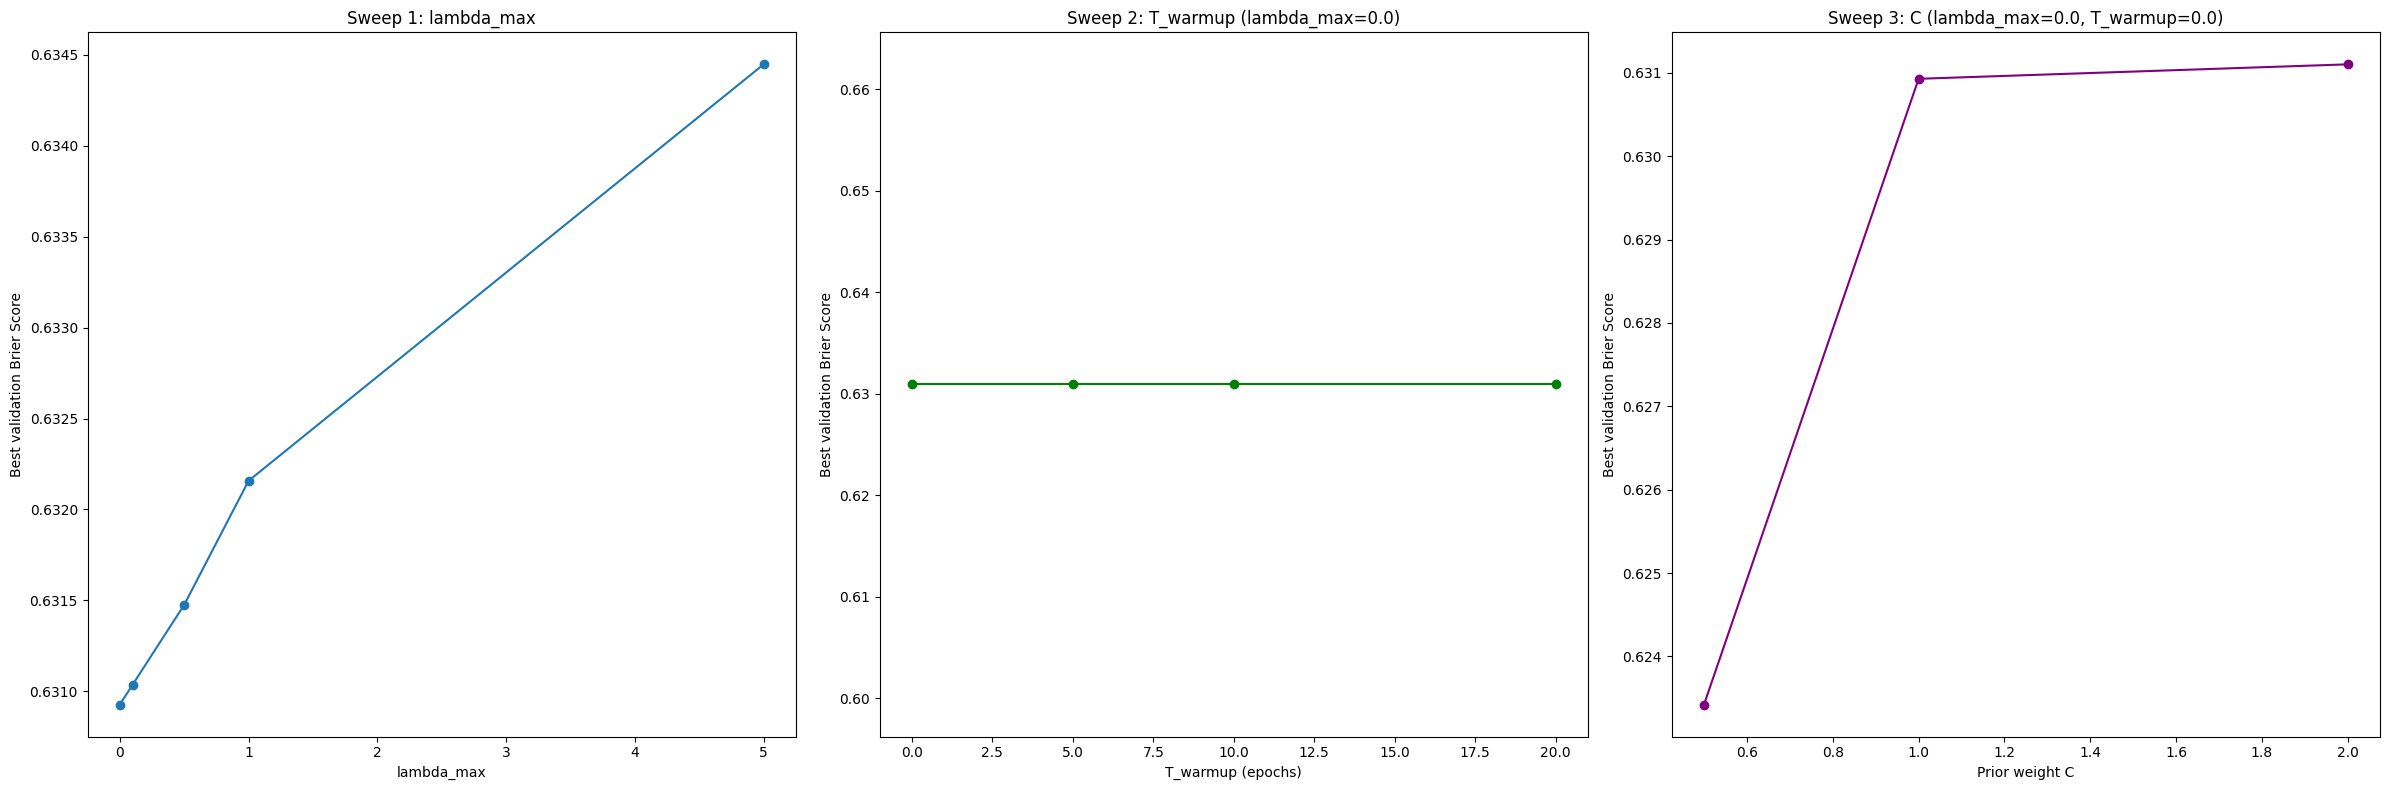

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

axes[0].plot(lambda_sweep_df["value"], lambda_sweep_df["best_val_brier"], marker="o")
axes[0].set_xlabel("lambda_max"); axes[0].set_ylabel("Best validation Brier Score")
axes[0].set_title("Sweep 1: lambda_max")

axes[1].plot(twarmup_sweep_df["value"], twarmup_sweep_df["best_val_brier"], marker="o", color="green")
axes[1].set_xlabel("T_warmup (epochs)"); axes[1].set_ylabel("Best validation Brier Score")
axes[1].set_title(f"Sweep 2: T_warmup (lambda_max={best_lambda_max})")

axes[2].plot(priorc_sweep_df["value"], priorc_sweep_df["best_val_brier"], marker="o", color="purple")
axes[2].set_xlabel("Prior weight C"); axes[2].set_ylabel("Best validation Brier Score")
axes[2].set_title(f"Sweep 3: C (lambda_max={best_lambda_max}, T_warmup={best_t_warmup})")

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["dir_plots_haal_ablation"], "haal_ablation_sweeps.png"), dpi=120)
plt.show()
plt.close(fig)


## 15. Final C1 training (full protocol, selected hyperparameters)

Checkpoints go to `checkpoints/fold_0/{best_model.pt, final_model.pt}` — this is
the official C1 model for fold 0.


[C1 final_fold0] epoch 01/50 loss=1.4546 (ce=1.4546 align=0.7388 lam_t=0.000) val_F1m=0.208 val_Brier=0.6234 (best 0.6234) patience=0/10
[C1 final_fold0] epoch 02/50 loss=1.2296 (ce=1.2296 align=0.7310 lam_t=0.000) val_F1m=0.208 val_Brier=0.6314 (best 0.6234) patience=1/10
[C1 final_fold0] epoch 03/50 loss=1.2030 (ce=1.2030 align=0.6542 lam_t=0.000) val_F1m=0.208 val_Brier=0.6319 (best 0.6234) patience=2/10
[C1 final_fold0] epoch 04/50 loss=1.1288 (ce=1.1288 align=0.6515 lam_t=0.000) val_F1m=0.208 val_Brier=0.6366 (best 0.6234) patience=3/10
[C1 final_fold0] epoch 05/50 loss=0.9971 (ce=0.9971 align=0.6212 lam_t=0.000) val_F1m=0.208 val_Brier=0.6396 (best 0.6234) patience=4/10
[C1 final_fold0] epoch 06/50 loss=1.0090 (ce=1.0090 align=0.6126 lam_t=0.000) val_F1m=0.208 val_Brier=0.6411 (best 0.6234) patience=5/10
[C1 final_fold0] epoch 07/50 loss=0.9106 (ce=0.9106 align=0.5730 lam_t=0.000) val_F1m=0.208 val_Brier=0.6462 (best 0.6234) patience=6/10
[C1 final_fold0] epoch 08/50 loss=0.9047 

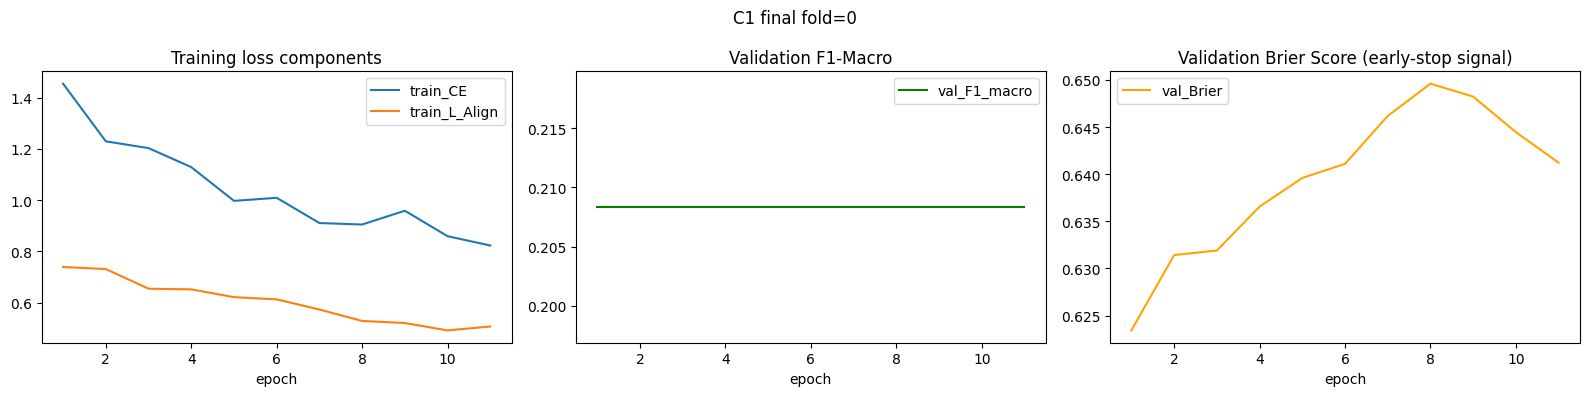

Saved best checkpoint:  /content/drive/MyDrive/LIDC_Thesis/experiments/C1_ConvNeXtV2T_EDL_HAAL/checkpoints/fold_0/best_model.pt
Saved final checkpoint: /content/drive/MyDrive/LIDC_Thesis/experiments/C1_ConvNeXtV2T_EDL_HAAL/checkpoints/fold_0/final_model.pt


In [ ]:
set_seed(CONFIG["seed"])

c1_model, c1_history_df, c1_best_ckpt, c1_final_ckpt, c1_best_val_brier = train_c1_once(
    train_loader, val_loader, CONFIG,
    lambda_max=best_lambda_max, t_warmup=best_t_warmup, prior_c=best_prior_c,
    max_epochs=CONFIG["epochs"], patience=CONFIG["early_stop_patience"],
    run_name="final_fold0", ckpt_dir=CONFIG["dir_ckpt_fold0"],
)

# logs/training_log.csv - the FINAL run's per-epoch history (ablation histories live separately
# under logs/ablation_runs/
c1_history_df.to_csv(os.path.join(CONFIG["dir_logs"], "training_log.csv"), index=False)

plot_training_curves(c1_history_df, "C1 final fold=0", CONFIG["dir_plots_training"])
log(f"Saved best checkpoint:  {c1_best_ckpt}")
log(f"Saved final checkpoint: {c1_final_ckpt}")


## 16. Held-out test evaluation, full metrics breakdown, and plots

Evaluates the best fold-0 checkpoint on the held-out test set, then writes every metrics file
in the template expects (`classification/`, `calibration/`, `uncertainty/`) and generates all five
plot types (`training_curves` already done above; `confusion_matrices`, `roc_curves`,
`calibration_diagrams` + `reliability_diagrams`, `rejection_curves`).


In [ ]:
c1_test_metrics, c1_preds_df, c1_test_probs, c1_test_y, c1_test_u = evaluate_c1_on_test(
    c1_model, test_loader, CONFIG, prior_c=best_prior_c)

log("C1 fold-0 TEST metrics:")
for k in ["f1_macro", "auroc_macro", "brier", "ece", "nll"]:
    log(f"  {k}: {c1_test_metrics[k]:.4f}")

# ---- predictions/deterministic/fold_0_predictions.csv ----
col_patient = CONFIG["column_map"]["patient_id"]
col_nodule = CONFIG["column_map"]["nodule_id"]
test_df_reset = test_df.reset_index(drop=True)
id_cols = test_df_reset[[col_nodule, col_patient]].reset_index().rename(columns={"index": "row_index"})
c1_preds_df = c1_preds_df.merge(id_cols, on="row_index", how="left")

preds_path = os.path.join(CONFIG["dir_predictions"], "fold_0_predictions.csv")
c1_preds_df.to_csv(preds_path, index=False)
log(f"Saved per-nodule test predictions to: {preds_path}")


C1 fold-0 TEST metrics:
  f1_macro: 0.2370
  auroc_macro: 0.5470
  brier: 0.6319
  ece: 0.1269
  nll: 1.0489
Saved per-nodule test predictions to: /content/drive/MyDrive/LIDC_Thesis/experiments/C1_ConvNeXtV2T_EDL_HAAL/predictions/deterministic/fold_0_predictions.csv


In [ ]:
# ---- metrics/classification/{fold_metrics.csv, overall_metrics.csv} ----
classification_row = pd.DataFrame([{
    "fold": FOLD0_SELECTOR,
    "f1_macro": c1_test_metrics["f1_macro"],
    "f1_benign": c1_test_metrics["f1_benign"],
    "f1_indeterminate": c1_test_metrics["f1_indeterminate"],
    "f1_malignant": c1_test_metrics["f1_malignant"],
    "auroc_macro": c1_test_metrics["auroc_macro"],
    "n_test": c1_test_metrics["n_test"],
}])
classification_row.to_csv(os.path.join(CONFIG["dir_metrics_classification"], "fold_metrics.csv"), index=False)
# "overall" == fold-0 result until the Weeks 8-9 full 5-fold run adds the other folds.
classification_row.to_csv(os.path.join(CONFIG["dir_metrics_classification"], "overall_metrics.csv"), index=False)

# ---- metrics/calibration/{brier_scores.csv, ece_scores.csv, nll_scores.csv} ----
pd.DataFrame([{"fold": FOLD0_SELECTOR, "brier": c1_test_metrics["brier"]}]).to_csv(
    os.path.join(CONFIG["dir_metrics_calibration"], "brier_scores.csv"), index=False)
pd.DataFrame([{"fold": FOLD0_SELECTOR, "ece": c1_test_metrics["ece"]}]).to_csv(
    os.path.join(CONFIG["dir_metrics_calibration"], "ece_scores.csv"), index=False)
pd.DataFrame([{"fold": FOLD0_SELECTOR, "nll": c1_test_metrics["nll"]}]).to_csv(
    os.path.join(CONFIG["dir_metrics_calibration"], "nll_scores.csv"), index=False)

# ---- metrics/uncertainty/{entropy_summary.csv, rejection_curves.csv} ----
# (no variation_ratio.csv - that metric is specific to MC-Dropout models like B1, not C1)
entropy_summary = pd.DataFrame([{
    "fold": FOLD0_SELECTOR,
    "u_mean": float(np.mean(c1_test_u)), "u_std": float(np.std(c1_test_u)),
    "u_min": float(np.min(c1_test_u)), "u_max": float(np.max(c1_test_u)),
}])
entropy_summary.to_csv(os.path.join(CONFIG["dir_metrics_uncertainty"], "entropy_summary.csv"), index=False)

rejection_df = compute_rejection_curve(c1_test_y, c1_test_probs, c1_test_u)
rejection_df.to_csv(os.path.join(CONFIG["dir_metrics_uncertainty"], "rejection_curves.csv"), index=False)

log(f"Saved classification/calibration/uncertainty metrics under: {os.path.join(CONFIG['exp_root'], 'metrics')}")


Saved classification/calibration/uncertainty metrics under: /content/drive/MyDrive/LIDC_Thesis/experiments/C1_ConvNeXtV2T_EDL_HAAL/metrics


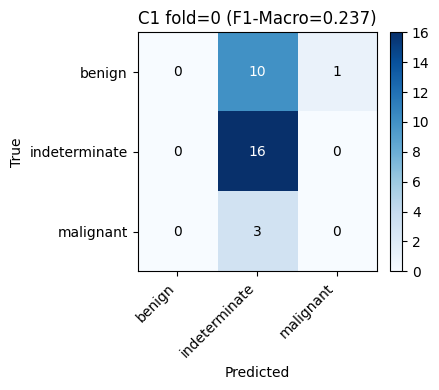

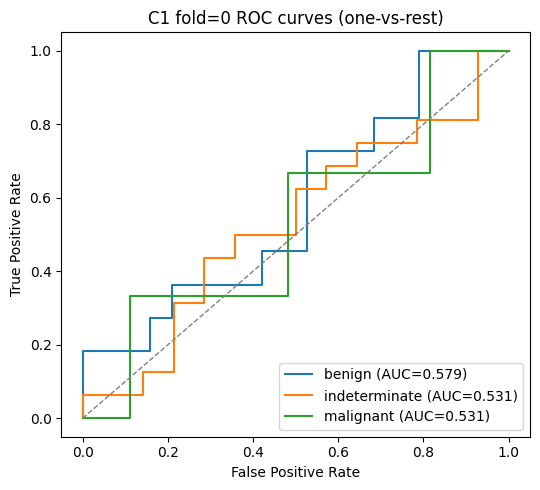

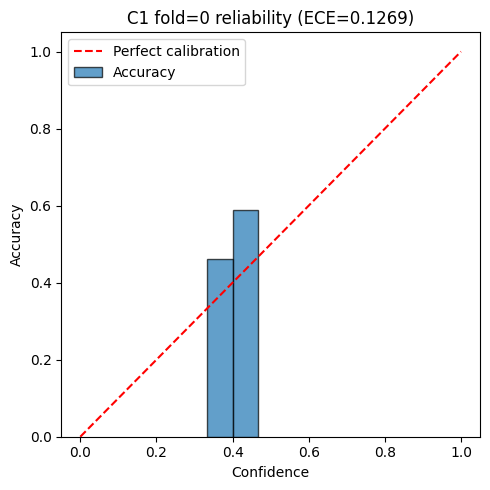

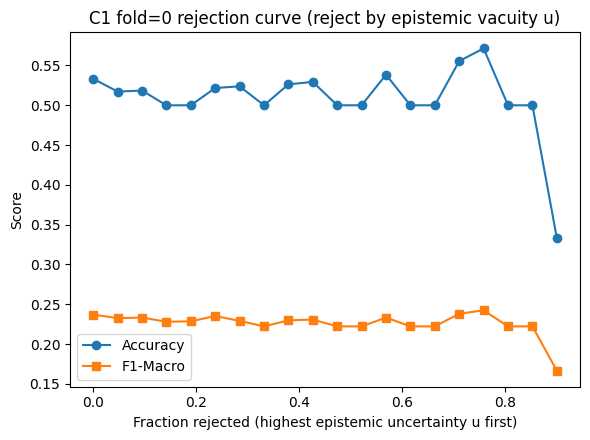

In [ ]:
# ---- plots/confusion_matrices/, roc_curves/, calibration_diagrams/ + reliability_diagrams/, rejection_curves/ ----
plot_confusion_matrix(
    np.array(c1_test_metrics["confusion_matrix"]), CONFIG["class_names"],
    f"C1 fold=0 (F1-Macro={c1_test_metrics['f1_macro']:.3f})", CONFIG["dir_plots_confusion"])

plot_roc_curves(c1_test_y, c1_test_probs, CONFIG["class_names"],
                 "C1 fold=0 ROC curves (one-vs-rest)", CONFIG["dir_plots_roc"])

plot_reliability_diagram(
    c1_test_metrics["ece_bins_df"], c1_test_metrics["ece"], "C1 fold=0 reliability",
    CONFIG["dir_plots_reliability"], CONFIG["dir_plots_calibration"])

plot_rejection_curve(rejection_df, "C1 fold=0 rejection curve (reject by epistemic vacuity u)",
                      CONFIG["dir_plots_rejection"])


## 17. Milestone M3 check

In [ ]:
b3_fold0_brier = None
b3_source_used = None

for candidate in CONFIG["b3_results_candidates"]:
    candidate_path = os.path.join(CONFIG["drive_root"], candidate)
    if not os.path.exists(candidate_path):
        log(f"B3 results not found at: {candidate_path}")
        continue
    week4_5_df = pd.read_csv(candidate_path)
    b3_rows = week4_5_df[
        (week4_5_df["model"] == "B3") & (week4_5_df["split"].astype(str) == str(FOLD0_SELECTOR))
    ]
    if len(b3_rows) > 0:
        b3_fold0_brier = float(b3_rows.iloc[0]["brier"])
        b3_source_used = candidate_path
        log(f"Found B3 fold-0 test Brier Score in: {candidate_path} -> {b3_fold0_brier:.4f}")
        break
    else:
        log(f"File found but no B3/fold-{FOLD0_SELECTOR} row in: {candidate_path}")

if b3_fold0_brier is None:
    log("[WARNING] Could not find a B3 fold-0 result in any candidate location. "
        "The M3 calibration comparison below will be skipped. Run the Weeks 4-5 notebook first "
        "(at least through fold 0 for B3), or add the correct path to CONFIG['b3_results_candidates'].")


B3 results not found at: /content/drive/MyDrive/LIDC_Thesis/experiments/B3_ResNet50_EDL/reports/B3_results_summary.csv
B3 results not found at: /content/drive/MyDrive/LIDC_Thesis/outputs/week4_5_baselines/results/baseline_B1_B3_results.csv
[WARNING] Could not find a B3 fold-0 result in any candidate location. The M3 calibration comparison below will be skipped. Run the Weeks 4-5 notebook first (at least through fold 0 for B3), or add the correct path to CONFIG['b3_results_candidates'].


MILESTONE M3 CHECK - end of Weeks 6-8
Calibration check: SKIPPED (no B3 fold-0 result available).
Alignment loss, first 3 epochs after warm-up (epoch 0): 0.7080
Alignment loss, last 3 epochs of training:                    0.5061
Alignment convergence check: PASS


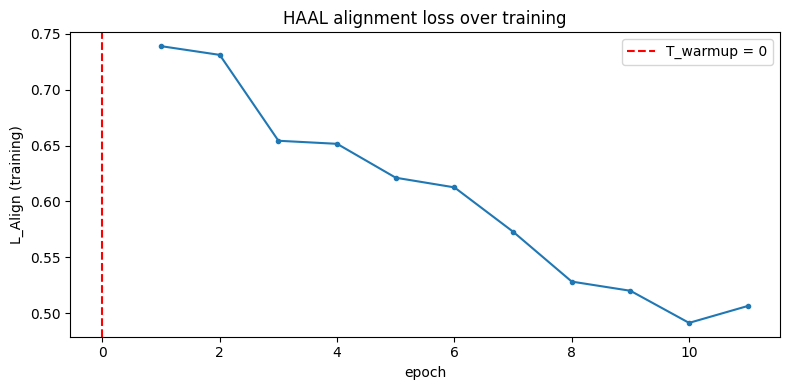

M3 result INCOMPLETE - re-check the warnings above before treating this as a pass or fail.


In [ ]:
log("=" * 78)
log("MILESTONE M3 CHECK")
log("=" * 78)

calibration_pass = None
if b3_fold0_brier is not None:
    c1_fold0_brier = c1_test_metrics["brier"]
    calibration_pass = c1_fold0_brier <= b3_fold0_brier
    log(f"C1 (ConvNeXt V2-T + EDL + HAAL) fold-0 test Brier: {c1_fold0_brier:.4f}")
    log(f"B3 (ResNet50 + vanilla EDL)     fold-0 test Brier: {b3_fold0_brier:.4f}  (from {b3_source_used})")
    log(f"Calibration check: {'PASS' if calibration_pass else 'FAIL'} (C1 Brier <= B3 Brier)")
else:
    log("Calibration check: SKIPPED (no B3 fold-0 result available).")

t_warm = int(best_t_warmup)
post_warmup = c1_history_df[c1_history_df["epoch"] > t_warm]

alignment_converging = None
if len(post_warmup) >= 6:
    early_window = post_warmup["train_align"].iloc[:3].mean()
    late_window = post_warmup["train_align"].iloc[-3:].mean()
    alignment_converging = late_window < early_window
    log(f"Alignment loss, first 3 epochs after warm-up (epoch {t_warm}): {early_window:.4f}")
    log(f"Alignment loss, last 3 epochs of training:                    {late_window:.4f}")
    log(f"Alignment convergence check: {'PASS' if alignment_converging else 'FAIL'}")
else:
    log(f"Alignment convergence check: SKIPPED (fewer than 6 epochs ran after warm-up "
        f"ended at epoch {t_warm}).")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(c1_history_df["epoch"], c1_history_df["train_align"], marker="o", markersize=3)
ax.axvline(t_warm, color="red", linestyle="--", label=f"T_warmup = {t_warm}")
ax.set_xlabel("epoch"); ax.set_ylabel("L_Align (training)")
ax.set_title("HAAL alignment loss over training")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["dir_plots_haal_ablation"], "C1_alignment_loss_curve.png"), dpi=120)
plt.show()
plt.close(fig)

log("=" * 78)
if calibration_pass and alignment_converging:
    m3_verdict = "PASSED"
    log("M3 PASSED. Proceed to Weeks 8-9: train B2 (ConvNeXt V2 + MC Dropout), then run the "
        "full 5-fold protocol for B1, B2, B3, and C1 using these HAAL hyperparameters.")
elif calibration_pass is None or alignment_converging is None:
    m3_verdict = "INCOMPLETE"
    log("M3 result INCOMPLETE - re-check the warnings above before treating this as a pass or fail.")
else:
    m3_verdict = "NOT PASSED"
    log("M3 NOT PASSED on fold 0. Per the plan's contingency: reduce the lambda_max range "
        "(e.g. drop 5.0 from CONFIG['lambda_max_grid']) or replace the squared-error L_Align with "
        "a soft correlation penalty between H_al_tilde and V, then re-run Section 14.")
log("=" * 78)


## 18. Reports and README

Writes `reports/C1_results_summary.csv`, `reports/C1_results_summary.json`,
`reports/C1_experiment_notes.md`, and a short `README.md` for the experiment folder.


In [ ]:
summary_dict = {
    "experiment_id": CONFIG["experiment_id"],
    "backbone": "ConvNeXt V2-T",
    "uq_method": "EDL + HAAL",
    "fold": FOLD0_SELECTOR,
    "selected_lambda_max": best_lambda_max,
    "selected_t_warmup": best_t_warmup,
    "selected_prior_c": best_prior_c,
    "test_f1_macro": c1_test_metrics["f1_macro"],
    "test_auroc_macro": c1_test_metrics["auroc_macro"],
    "test_brier": c1_test_metrics["brier"],
    "test_ece": c1_test_metrics["ece"],
    "test_nll": c1_test_metrics["nll"],
    "b3_fold0_brier_compared_against": b3_fold0_brier,
    "m3_verdict": m3_verdict,
    "run_timestamp": datetime.now().isoformat(),
}

pd.DataFrame([summary_dict]).to_csv(os.path.join(CONFIG["dir_reports"], "C1_results_summary.csv"), index=False)
with open(os.path.join(CONFIG["dir_reports"], "C1_results_summary.json"), "w") as f:
    jsonlib.dump(summary_dict, f, indent=2)

notes_md = f"""# C1 (ConvNeXt V2-T + EDL + HAAL) — Experiment Notes

**Run date:** {datetime.now().strftime('%Y-%m-%d %H:%M')}
**Fold:** {FOLD0_SELECTOR}

## Selected HAAL hyperparameters
- lambda_max = {best_lambda_max}
- T_warmup   = {best_t_warmup}
- prior C    = {best_prior_c}

(Selected via sequential one-factor-at-a-time search on fold-0 validation Brier Score —
see `metrics/haal_ablation/` for the full sweep tables.)

## Fold-0 test results
| Metric | Value |
|---|---|
| F1-Macro | {c1_test_metrics['f1_macro']:.4f} |
| AUROC (macro) | {c1_test_metrics['auroc_macro']:.4f} |
| Brier Score | {c1_test_metrics['brier']:.4f} |
| ECE | {c1_test_metrics['ece']:.4f} |
| NLL | {c1_test_metrics['nll']:.4f} |

## Milestone M3 verdict: **{m3_verdict}**
- B3 fold-0 test Brier Score compared against: {b3_fold0_brier}
- Source of B3 result: {b3_source_used}

"""
with open(os.path.join(CONFIG["dir_reports"], "C1_experiment_notes.md"), "w") as f:
    f.write(notes_md)

readme_md = f"""# {CONFIG['experiment_id']}

ConvNeXt V2-T backbone, EDL + HAAL uncertainty quantification (Configuration C1, Table 3 of the
proposal). This folder was produced by `LIDC_IDRI_HAAL_C1_Training_Week6to8.ipynb`.

See `reports/C1_experiment_notes.md` for a full summary of this run, including the Milestone M3
verdict and the selected HAAL hyperparameters.
"""
with open(os.path.join(CONFIG["exp_root"], "README.md"), "w") as f:
    f.write(readme_md)

log(f"Saved reports and README under: {CONFIG['exp_root']}")


Saved reports and README under: /content/drive/MyDrive/LIDC_Thesis/experiments/C1_ConvNeXtV2T_EDL_HAAL


## 19. Summary

All outputs for this run live under:

```
{drive_root}/experiments/C1_ConvNeXtV2T_EDL_HAAL/
```


